<a href="https://colab.research.google.com/github/navneetkrc/Deep-Learning-Experiments-implemented-using-Google-Colab/blob/master/ANCE_Query_Reformulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# samsung_ance_colab.ipynb (Python script version for Colab)

# =========================================
# 📦 1. Install Dependencies
# =========================================
!pip install sentence-transformers faiss-cpu pandas datasets

In [ ]:
# =========================================
# 🧪 2. Generate Synthetic Samsung E-commerce Data
# =========================================
# !pip install -q sentence-transformers faiss-cpu pandas datasets

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from datasets import Dataset
import faiss
import pandas as pd
import numpy as np
import os


os.makedirs("data", exist_ok=True)

queries = [
    {"query_id": i, "query": q} for i, q in enumerate([
        "galaxy s23 ultra case",
        "65 inch smart tv",
        "wireless earbuds for running",
        "black french door refrigerator",
        "tablet with s pen",
        "bespoke washing machine",
        "ultra hd monitor",
        "gaming laptop with rtx",
        "curved screen monitor",
        "portable air conditioner"
    ])
]

products = [
    {"product_id": i, "title": t, "description": d}
    for i, (t, d) in enumerate([
        ("Galaxy S23 Ultra Protective Case", "Durable case for S23 Ultra, shockproof and slim design."),
        ("Samsung 65-Inch QLED Smart TV", "4K UHD, HDR, Smart Hub, Voice Assistant Enabled."),
        ("Galaxy Buds2 Pro", "Noise canceling wireless earbuds with long battery life."),
        ("Bespoke Black French Door Refrigerator", "Customizable design, energy efficient, large capacity."),
        ("Galaxy Tab S8 with S Pen", "Powerful tablet with stylus, ideal for creators."),
        ("Bespoke Washing Machine AI Control", "Smart washing with AI wash cycles and eco-bubble technology."),
        ("Samsung 32 inch UHD Monitor", "Ultra HD display with vibrant color and fast refresh rate."),
        ("Galaxy Book Pro Gaming Laptop", "Intel i7, RTX 3060, AMOLED display."),
        ("Samsung Curved Monitor 27-Inch", "Immersive curve, eye comfort, full HD."),
        ("Samsung Portable AC 1.5 Ton", "Powerful portable cooling with inverter tech.")
    ])
]

co_purchases = [
    {"query_id": i, "product_id": i} for i in range(len(queries))
]

pd.DataFrame(queries).to_csv("data/queries.csv", index=False)
pd.DataFrame(products).to_csv("data/products.csv", index=False)
pd.DataFrame(co_purchases).to_csv("data/co_purchase_log.csv", index=False)

print("✅ Synthetic data generated!")

In [ ]:
# =========================================
# 🧠 3. ANCE Mining and Bi-Encoder Training
# =========================================
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import faiss
import numpy as np
from datasets import Dataset


queries = pd.read_csv("data/queries.csv")
products = pd.read_csv("data/products.csv")
co_purchases = pd.read_csv("data/co_purchase_log.csv")

products["text"] = products["title"] + " " + products["description"]
product_texts = products["text"].tolist()

biencoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
product_embeddings = biencoder.encode(product_texts, show_progress_bar=True, convert_to_numpy=True)
faiss.normalize_L2(product_embeddings)
index = faiss.IndexFlatIP(product_embeddings.shape[1])
index.add(product_embeddings)

triplets = []
top_k = 20
query_embeddings = biencoder.encode(queries["query"].tolist(), show_progress_bar=True, convert_to_numpy=True)
faiss.normalize_L2(query_embeddings)
D, I = index.search(query_embeddings, top_k)

for i, (scores, indices) in enumerate(zip(D, I)):
    qid = queries.iloc[i]['query_id']
    qtxt = queries.iloc[i]['query']
    positive_ids = co_purchases[co_purchases['query_id'] == qid]['product_id'].tolist()
    if not positive_ids:
        continue
    positive_text = products[products['product_id'] == positive_ids[0]]['text'].values[0]
    for pid in indices:
        neg_id = products.iloc[pid]['product_id']
        if neg_id not in positive_ids:
            negative_text = products.iloc[pid]['text']
            triplets.append(InputExample(texts=[qtxt, positive_text, negative_text]))
            break

print(f"✅ {len(triplets)} training triplets ready!")

train_dataloader = DataLoader(triplets, shuffle=True, batch_size=4)
train_loss = losses.TripletLoss(model=biencoder)

biencoder.fit(train_objectives=[(train_dataloader, train_loss)],
              epochs=1,
              warmup_steps=10,
              show_progress_bar=True)

biencoder.save("models/biencoder")
print("✅ Bi-encoder model saved to /models/biencoder")

In [ ]:
# =========================================
# 📌 4. Test Retrieval with Trained Bi-Encoder
# =========================================
def test_query_retrieval(user_query, top_k=3):
    q_embed = biencoder.encode([user_query], convert_to_numpy=True)
    faiss.normalize_L2(q_embed)
    D, I = index.search(q_embed, top_k)
    print(f"\n🔍 Results for: '{user_query}'")
    for rank, idx in enumerate(I[0]):
        p = products.iloc[idx]
        print(f"[{rank+1}] {p['title']} - {p['description']}")

# Run test
sample_query = "best smart tv with voice assistant"
test_query_retrieval(sample_query)

In [ ]:
# =========================================
# 🧠 5. Fine-tune Cross-Encoder on ANCE Mined Data
# =========================================
from sentence_transformers import CrossEncoder

pairwise_data = [
    InputExample(texts=[triplet.texts[0], triplet.texts[1]], label=1.0) for triplet in triplets
] + [
    InputExample(texts=[triplet.texts[0], triplet.texts[2]], label=0.0) for triplet in triplets
]

train_dataloader = DataLoader(pairwise_data, shuffle=True, batch_size=4)

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", num_labels=1)

cross_encoder.fit(
    train_dataloader=train_dataloader,
    epochs=1,
    warmup_steps=10,
    show_progress_bar=True
)

cross_encoder.save("models/cross_encoder")
print("✅ Cross-encoder model saved to /models/cross_encoder")

In [ ]:
# =========================================
# 🔍 6. Compare Bi-Encoder vs Cross-Encoder Ranking (w/ MRR@3)
# =========================================
def evaluate_ranking(top_k=3):
    mrr_bi, mrr_cross = 0, 0

    for _, row in queries.iterrows():
        query = row['query']
        qid = row['query_id']
        gt_pid = co_purchases[co_purchases['query_id'] == qid]['product_id'].values[0]

        # Bi-encoder Retrieval
        q_embed = biencoder.encode([query], convert_to_numpy=True)
        faiss.normalize_L2(q_embed)
        D, I = index.search(q_embed, top_k)
        retrieved_pids = [products.iloc[i]['product_id'] for i in I[0]]

        if gt_pid in retrieved_pids:
            rank = retrieved_pids.index(gt_pid) + 1
            mrr_bi += 1.0 / rank

        # Cross-encoder Re-ranking
        candidate_texts = [products.iloc[i]['text'] for i in I[0]]
        input_pairs = [[query, p] for p in candidate_texts]
        scores = cross_encoder.predict(input_pairs)
        reranked = sorted(zip(I[0], scores), key=lambda x: x[1], reverse=True)
        reranked_pids = [products.iloc[i]['product_id'] for i, _ in reranked]

        if gt_pid in reranked_pids:
            rank = reranked_pids.index(gt_pid) + 1
            mrr_cross += 1.0 / rank

    mrr_bi /= len(queries)
    mrr_cross /= len(queries)

    print(f"\n📊 MRR@{top_k} Bi-Encoder: {mrr_bi:.3f}")
    print(f"📊 MRR@{top_k} Cross-Encoder: {mrr_cross:.3f}")

evaluate_ranking(top_k=3)

##on AMazon data

In [1]:
!pip install --upgrade gcsfs fsspec==2025.3.2
!pip install sentence-transformers faiss-cpu pandas datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from datasets import Dataset
import faiss
import pandas as pd
import numpy as np
import os


In [3]:
# Bi-Encoder and Cross-Encoder Evaluation on Amazon ESCI Dataset

# ✅ 1. Load Dataset (Amazon ESCI from HuggingFace)
from datasets import load_dataset

# data = load_dataset("milistu/amazon-esci-data", "products")
# data = load_dataset("milistu/amazon-esci-data", "queries")
# print("Loaded the 'queries' configuration.")
# print(data)

In [4]:
from datasets import load_dataset
data_queries = load_dataset("milistu/amazon-esci-data", name="queries")
print("Loaded the 'queries' configuration.")
print(data_queries)

README.md:   0%|          | 0.00/5.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/47.9M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/15.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1983272 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/638016 [00:00<?, ? examples/s]

Loaded the 'queries' configuration.
DatasetDict({
    train: Dataset({
        features: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split', '__index_level_0__'],
        num_rows: 1983272
    })
    test: Dataset({
        features: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split', '__index_level_0__'],
        num_rows: 638016
    })
})


In [5]:
from datasets import load_dataset
data_sources = load_dataset("milistu/amazon-esci-data", name="sources")
print("Loaded the 'sources' configuration.")
print(data_sources)

train-00000-of-00001.parquet:   0%|          | 0.00/1.15M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/360k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99683 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/30969 [00:00<?, ? examples/s]

Loaded the 'sources' configuration.
DatasetDict({
    train: Dataset({
        features: ['query_id', 'source', 'split', '__index_level_0__'],
        num_rows: 99683
    })
    test: Dataset({
        features: ['query_id', 'source', 'split', '__index_level_0__'],
        num_rows: 30969
    })
})


In [6]:
from datasets import load_dataset
data_products = load_dataset("milistu/amazon-esci-data", name="products")
print("Loaded the 'products' configuration.")
print(data_products)

train-00000-of-00004.parquet:   0%|          | 0.00/222M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/203M [00:00<?, ?B/s]

train-00003-of-00004.parquet:   0%|          | 0.00/218M [00:00<?, ?B/s]

test-00000-of-00002.parquet:   0%|          | 0.00/147M [00:00<?, ?B/s]

test-00001-of-00002.parquet:   0%|          | 0.00/139M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1371823 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/443101 [00:00<?, ? examples/s]

Loaded the 'products' configuration.
DatasetDict({
    train: Dataset({
        features: ['product_id', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_locale', 'split', '__index_level_0__'],
        num_rows: 1371823
    })
    test: Dataset({
        features: ['product_id', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_locale', 'split', '__index_level_0__'],
        num_rows: 443101
    })
})


In [7]:
from datasets import load_dataset
import pandas as pd
import random
from sentence_transformers import InputExample

# Load both configs
queries = load_dataset("milistu/amazon-esci-data", "queries")["train"]
products = load_dataset("milistu/amazon-esci-data", "products")["train"]

# Convert to pandas
queries_df = queries.to_pandas()
products_df = products.to_pandas()

# Merge on product_id + locale
merged_df = pd.merge(queries_df, products_df, on=["product_id", "product_locale"])

# Filter to exact matches
exact_matches = merged_df[merged_df["esci_label"] == "E"]

# ✅ Take only 20,000 samples for faster processing
exact_matches_sampled = exact_matches.sample(n=20000, random_state=42)

# Triplet generation
def generate_triplets(df):
    triplets = []
    grouped = df.groupby("query")

    for query, group in grouped:
        titles = group["product_title"].tolist()
        if len(titles) < 2:
            continue  # skip if not enough for pos/neg
        for i in range(len(titles) - 1):
            pos = titles[i]
            neg_candidates = [t for t in titles if t != pos]
            if neg_candidates:
                neg = random.choice(neg_candidates)
                triplets.append(InputExample(texts=[query, pos, neg]))
    return triplets

train_triplets = generate_triplets(exact_matches_sampled)
print(f"✅ {len(train_triplets)} training triplets ready (from 20K sample)!")


✅ 2312 training triplets ready (from 20K sample)!


In [8]:
# ✅ 3. Train Bi-Encoder

from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses

# Initialize your bi-encoder model
biencoder = SentenceTransformer("all-MiniLM-L6-v2")

# Create a DataLoader
train_dataloader = DataLoader(train_triplets, shuffle=True, batch_size=16)

# Define a Triplet loss
train_loss = losses.TripletLoss(model=biencoder)

# Train the model (for 1 epoch as a test)
biencoder.fit(train_objectives=[(train_dataloader, train_loss)],
              epochs=1,
              warmup_steps=10,
              show_progress_bar=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: navneetkrch (navneetkrch-samsung-research) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss


In [9]:
# ✅ 4. Cross-Encoder Fine-tuning
import torch
from torch.utils.data import DataLoader, Dataset
from sentence_transformers import CrossEncoder
from sentence_transformers import InputExample

# Create a PyTorch Dataset
class CrossEncoderDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Subset for training
subset_df = merged_df[merged_df["esci_label"].isin(["E", "I"])].sample(n=10000, random_state=42)



# Build training examples using InputExample
crossencoder_data = [
    InputExample(texts=[row["query"], row["product_title"]], label=1.0 if row["esci_label"] == "E" else 0.0)
    for _, row in subset_df.iterrows()
]

class CrossEncoderDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = CrossEncoderDataset(crossencoder_data)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

crossencoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', num_labels=1)

crossencoder.fit(
    train_dataloader=train_dataloader,
    epochs=1,
    warmup_steps=10,
    show_progress_bar=True
)




config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/625 [00:00<?, ?it/s]

In [10]:
# ✅ 5. Evaluation: MRR@3
from datasets import load_dataset
import pandas as pd

# Load the test splits of queries and products
queries_test = load_dataset("milistu/amazon-esci-data", "queries")["test"]
products_test = load_dataset("milistu/amazon-esci-data", "products")["test"]

# Convert to pandas
queries_df = queries_test.to_pandas()
products_df = products_test.to_pandas()

# Merge on product_id and locale
merged_test_df = pd.merge(queries_df, products_df, on=["product_id", "product_locale"])

# Optionally filter to only certain locales if needed (e.g., 'us')
# merged_test_df = merged_test_df[merged_test_df['product_locale'] == 'us']

# Optional: For faster testing, sample only 500-1000 query-product examples
test_sample = merged_test_df.sample(n=1000, random_state=42)


In [11]:
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_mrr(test_data, biencoder, crossencoder, k=3):
    mrr_scores = []
    queries = defaultdict(list)

    for row in test_data:
        queries[row["query"]].append(row)

    for query_text, items in queries.items():
        candidates = [item["product_title"] for item in items]
        if len(candidates) < k:
            continue  # Skip if we don't have enough candidates

        query_embedding = biencoder.encode(query_text, convert_to_tensor=True)
        candidate_embeddings = biencoder.encode(candidates, convert_to_tensor=True)
        scores = np.dot(candidate_embeddings.cpu().numpy(), query_embedding.cpu().numpy())
        ranked = sorted(zip(items, scores), key=lambda x: x[1], reverse=True)

        for rank, (item, _) in enumerate(ranked[:k]):
            if item["esci_label"] == "exact":
                mrr_scores.append(1 / (rank + 1))
                break
        else:
            mrr_scores.append(0)

    return np.mean(mrr_scores)


In [12]:
mrr_score = evaluate_mrr(test_sample.to_dict("records"), biencoder, crossencoder)
print("✅ MRR@3:", mrr_score)


✅ MRR@3: nan


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:
# ✅ 6. Save Models
biencoder.save("biencoder-amazon-esci")
crossencoder.save("crossencoder-amazon-esci")

In [14]:
!pip install -q streamlit pyngrok sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.0 MB/s eta 0:00:00


In [15]:
%%writefile app.py
import streamlit as st
from sentence_transformers import SentenceTransformer, CrossEncoder
import pandas as pd
import numpy as np

# Load pretrained models
bi_model = SentenceTransformer("all-MiniLM-L6-v2")
cross_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Sample queries and product titles
sample_data = pd.DataFrame({
    "query": [
        "wireless bluetooth earbuds",
        "gaming laptop",
        "smartwatch with heart rate monitor"
    ],
    "product_titles": [
        [
            "Bluetooth Earbuds Wireless with Charging Case",
            "Wired In-Ear Headphones",
            "Noise Cancelling Over-Ear Headphones"
        ],
        [
            "High Performance Gaming Laptop - RTX 3060",
            "Budget Laptop with Intel UHD Graphics",
            "Portable Chromebook for Students"
        ],
        [
            "Smartwatch with ECG and Heart Rate Sensor",
            "Digital Watch for Kids",
            "Fitness Tracker with Step Counter"
        ]
    ]
})

st.title("Bi-Encoder vs Cross-Encoder Ranking Comparison")

query_idx = st.selectbox("Choose a sample query:", sample_data.index)
query = sample_data.loc[query_idx, "query"]
candidates = sample_data.loc[query_idx, "product_titles"]

# Bi-encoder ranking
query_embedding = bi_model.encode(query, convert_to_tensor=True)
candidate_embeddings = bi_model.encode(candidates, convert_to_tensor=True)
scores_bi = np.dot(candidate_embeddings.cpu().numpy(), query_embedding.cpu().numpy())
ranked_bi = sorted(zip(candidates, scores_bi), key=lambda x: x[1], reverse=True)

# Cross-encoder ranking
cross_inputs = [[query, c] for c in candidates]
scores_cross = cross_model.predict(cross_inputs)
ranked_cross = sorted(zip(candidates, scores_cross), key=lambda x: x[1], reverse=True)

st.subheader("Query")
st.markdown(f"> {query}")

col1, col2 = st.columns(2)

with col1:
    st.markdown("### Bi-Encoder Ranking")
    for title, score in ranked_bi:
        st.markdown(f"- **{title}** — `{score:.4f}`")

with col2:
    st.markdown("### Cross-Encoder Ranking")
    for title, score in ranked_cross:
        st.markdown(f"- **{title}** — `{score:.4f}`")


Writing app.py


In [16]:
import os
from google.colab import userdata
from pyngrok import ngrok

# Retrieve the ngrok token from Google Colab secrets
ngrok_token = userdata.get('NGROK_AUTH_TOKEN')

# Set the ngrok authentication token
ngrok.set_auth_token(ngrok_token)

# Start ngrok tunnel (specify port 8501 for Streamlit)
public_url = ngrok.connect(8501, "http")  # Ensure ngrok is using HTTP and port 8501
print(f"🌍 Your Streamlit app is live at: {public_url}")

# Run Streamlit app
!streamlit run app.py &


🌍 Your Streamlit app is live at: NgrokTunnel: "https://f723-34-125-117-56.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.117.56:8501

2025-04-20 15:58:31.552802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745164711.582614    2799 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745164711.594177    2799 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.11/dist-packages/streamlit/run

In [17]:
!pip install pyngrok
!pip install streamlit
!pip install sentence-transformers


In [18]:
from datasets import load_dataset
import pandas as pd

# Load the test splits of queries and products
queries_test = load_dataset("milistu/amazon-esci-data", "queries")["test"]
products_test = load_dataset("milistu/amazon-esci-data", "products")["test"]

# Convert to pandas
queries_df = queries_test.to_pandas()
products_df = products_test.to_pandas()

# Merge on product_id and locale
merged_test_df = pd.merge(queries_df, products_df, on=["product_id", "product_locale"])

# Sample 1000 query-product examples for testing
test_sample = merged_test_df.sample(n=1000, random_state=42)


In [19]:
%%writefile app.py
import streamlit as st
from sentence_transformers import SentenceTransformer, CrossEncoder
import pandas as pd
import numpy as np
from datasets import load_dataset

@st.cache_data
def load_data():
    # Load full test splits
    queries = load_dataset("milistu/amazon-esci-data", "queries")["test"].to_pandas()
    products = load_dataset("milistu/amazon-esci-data", "products")["test"].to_pandas()

    # Merge full dataset
    merged = pd.merge(queries, products, on=["product_id", "product_locale"])

    # Group by query to get product lists
    grouped = (
        merged.groupby("query")["product_title"]
        .apply(lambda x: list(set(x)))  # deduplicate
        .reset_index()
    )

    # Keep only queries with at least 5 products
    grouped["product_count"] = grouped["product_title"].apply(len)
    filtered = grouped[grouped["product_count"] >= 5].reset_index(drop=True)

    # For performance, sample only 200 queries
    return filtered.sample(n=200, random_state=42) if len(filtered) > 200 else filtered

@st.cache_resource
def load_models():
    bi = SentenceTransformer("all-MiniLM-L6-v2")
    cross = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    return bi, cross

# Load everything
valid_queries = load_data()
bi_model, cross_model = load_models()

st.title("🔍 Bi-Encoder vs Cross-Encoder Ranking")

if not valid_queries.empty:
    query_text = st.selectbox("Choose a sample query:", valid_queries["query"].tolist())
    query_row = valid_queries[valid_queries["query"] == query_text]

    if not query_row.empty:
        candidates = query_row.iloc[0]["product_title"][:10]  # get top 10 candidates

        # Bi-encoder ranking
        query_embedding = bi_model.encode(query_text, convert_to_tensor=True)
        candidate_embeddings = bi_model.encode(candidates, convert_to_tensor=True)
        scores_bi = np.dot(candidate_embeddings.cpu().numpy(), query_embedding.cpu().numpy())
        ranked_bi = sorted(zip(candidates, scores_bi), key=lambda x: x[1], reverse=True)[:5]

        # Cross-encoder ranking
        cross_inputs = [[query_text, c] for c in candidates]
        scores_cross = cross_model.predict(cross_inputs)
        ranked_cross = sorted(zip(candidates, scores_cross), key=lambda x: x[1], reverse=True)[:5]

        st.subheader("Query")
        st.markdown(f"> **{query_text}**")

        col1, col2 = st.columns(2)

        with col1:
            st.markdown("### 🔹 Bi-Encoder Top 5")
            for title, score in ranked_bi:
                st.markdown(f"- **{title}** — `{score:.4f}`")

        with col2:
            st.markdown("### 🔸 Cross-Encoder Top 5")
            for title, score in ranked_cross:
                st.markdown(f"- **{title}** — `{score:.4f}`")
    else:
        st.error("No products found for the selected query.")
else:
    st.error("No valid queries with enough product titles were found.")


Overwriting app.py


In [20]:
from pyngrok import ngrok

# Set up ngrok with the required auth token if needed
# Uncomment the next line if you haven't set up ngrok authentication yet
# ngrok.set_auth_token("your_ngrok_token")

# Open a tunnel on port 8501 (default Streamlit port)
public_url = ngrok.connect(8501)
print(f"🌍 Your Streamlit app is live at: {public_url}")


🌍 Your Streamlit app is live at: NgrokTunnel: "https://fe65-34-125-117-56.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.117.56:8501



# 🧠 Streamlit App for Bi-Encoder vs Cross-Encoder Ranking

## ✅ Objective
To **build a Streamlit app** that compares **bi-encoder** vs **cross-encoder** ranking performance on a real dataset of **product search queries**, helping visualize how well each model ranks products for a given query.

---

## 🧩 Tasks Completed

### 1. 📦 Loaded Real Dataset
- **Dataset:** `milistu/amazon-esci-data` from Hugging Face
- **Splits used:**
  - Queries: `"queries"` test split
  - Products: `"products"` test split
- **Merged** query and product data on `product_id` and `product_locale`
- **Sampled 1000 rows** for faster testing

> 🎯 *Use a realistic test set for meaningful product ranking comparisons.*

---

### 2. 🧠 Bi-Encoder and Cross-Encoder Setup
- **Bi-encoder model:** `all-MiniLM-L6-v2` (SentenceTransformers)
- **Cross-encoder model:** `cross-encoder/ms-marco-MiniLM-L-6-v2`

> 🎯 *Use both lightweight and heavyweight models to simulate real-world ranking differences.*

---

### 3. 🖥️ Streamlit App UI
- Built an interactive app with:
  - A dropdown to **select a sample query**
  - Display of **top 5 ranked product titles** for:
    - 🔹 Bi-encoder (cosine similarity)
    - 🔸 Cross-encoder (relevance score)
  - Displayed **ranking scores** alongside product titles

> 🎯 *Build an easy-to-use front end to visually compare model outputs.*

---

### 4. 🐛 Bug Fixes and Debugging
- Resolved issues such as:
  - Empty product lists for certain queries
  - Index errors on missing data
  - Improved "no result" messaging
- Updated logic to:
  - Show **top 5** ranked products
  - Handle edge cases gracefully

> 🎯 *Make the app stable, user-friendly, and useful for live demos or exploration.*

---

### 5. 🌐 Streamlit Hosting & Debugging
- Successfully launched app via Streamlit
- Handled:
  - CUDA/cuDNN warnings
  - Torch class watcher issues
- Verified final app working on external IP:  
  `http://34.125.211.77:8501`

> 🎯 *Ensure app is accessible and functions correctly in a live VM or notebook.*

---

## 🏁 Final Output
An interactive Streamlit app where you can:
- Select a query
- View how bi-encoder and cross-encoder rank the same products
- Compare their scores side-by-side

---

## 🔜 Possible Next Steps
- Add ranking metrics (e.g., NDCG@5, MRR)
- Allow **custom query input**
- Filter products by type, relevance, or locale
- Add visualizations (bar charts for score comparisons)

---



#Final edited version

In [ ]:
# 1️⃣ Install necessary libraries

!pip install -q streamlit sentence-transformers scikit-learn
!pip install -q cross-encoder  # Optional: some versions are included in sentence-transformers


In [ ]:
# 2️⃣ Import required Python libraries

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
# 3️⃣ Load ESCI test dataset and filter only "E" (Exact match) examples

def load_data():
    df = pd.read_csv("test.csv")  # Replace with correct path if needed
    return df[df["esci_label"] == "E"].reset_index(drop=True)

df = load_data()


In [ ]:
# 4️⃣ Load fine-tuned Bi-Encoder and Cross-Encoder models

bi = SentenceTransformer("biencoder-amazon-esci")       # Replace with your actual model name/path
cross = CrossEncoder("crossencoder-amazon-esci")        # Replace with your actual model name/path


In [ ]:
# 5️⃣ Define ranking functions for Bi-Encoder and Cross-Encoder

def rank_with_biencoder(query, products):
    embeddings = bi.encode([query] + products)
    query_vec = embeddings[0].reshape(1, -1)
    product_vecs = embeddings[1:]
    scores = cosine_similarity(query_vec, product_vecs)[0]
    return scores

def rank_with_crossencoder(query, products):
    pairs = [[query, p] for p in products]
    return cross.predict(pairs)


In [ ]:
# 6️⃣ Define MRR@k calculation (used for evaluating rankings)

def mrr_at_k(ranked_titles, ground_truth_titles, k=3):
    for i, title in enumerate(ranked_titles[:k]):
        if title in ground_truth_titles:
            return 1 / (i + 1)
    return 0


In [ ]:
# 7️⃣ Select query from dataset and compute Bi-Encoder + Cross-Encoder rankings

query = df["query"].sample(1).values[0]  # Or choose manually
print("Selected query:", query)

merged = df[df["query"] == query].copy()
products = merged["product_title"].tolist()

# Compute scores
bi_scores = rank_with_biencoder(query, products)
cross_scores = rank_with_crossencoder(query, products)

# Attach scores to dataframe
merged["bi_score"] = bi_scores
merged["cross_score"] = cross_scores

# Sort by scores
bi_ranked = merged.sort_values("bi_score", ascending=False).reset_index(drop=True)
cross_ranked = merged.sort_values("cross_score", ascending=False).reset_index(drop=True)


In [ ]:
# 8️⃣ Display top-5 results from both models with ESCI label

print("🔷 Bi-Encoder Top 5")
for i, row in bi_ranked.head(5).iterrows():
    print(f"{i+1}. {row['product_title']} | Score: {row['bi_score']:.4f} | Label: {row['esci_label']}")

print("\n🔶 Cross-Encoder Top 5")
for i, row in cross_ranked.head(5).iterrows():
    print(f"{i+1}. {row['product_title']} | Score: {row['cross_score']:.4f} | Label: {row['esci_label']}")


In [ ]:
# 9️⃣ Compute MRR@3 for the selected query

ground_truth_titles = merged[merged["esci_label"] == "E"]["product_title"].tolist()

bi_mrr = mrr_at_k(bi_ranked["product_title"].tolist(), ground_truth_titles)
cross_mrr = mrr_at_k(cross_ranked["product_title"].tolist(), ground_truth_titles)

print(f"\n📊 MRR@3 (Bi-Encoder): {bi_mrr:.3f}")
print(f"📊 MRR@3 (Cross-Encoder): {cross_mrr:.3f}")


In [ ]:
# 🔟 Loop over multiple queries and calculate average MRR@3

def evaluate_mrr_on_queries(df, k=3, max_queries=50):
    mrr_bi = []
    mrr_cross = []

    unique_queries = df["query"].unique()[:max_queries]

    for query in unique_queries:
        subset = df[df["query"] == query].copy()
        products = subset["product_title"].tolist()
        ground_truth = subset[subset["esci_label"] == "E"]["product_title"].tolist()

        bi_scores = rank_with_biencoder(query, products)
        cross_scores = rank_with_crossencoder(query, products)

        subset["bi_score"] = bi_scores
        subset["cross_score"] = cross_scores

        bi_ranked = subset.sort_values("bi_score", ascending=False)
        cross_ranked = subset.sort_values("cross_score", ascending=False)

        mrr_bi.append(mrr_at_k(bi_ranked["product_title"].tolist(), ground_truth, k))
        mrr_cross.append(mrr_at_k(cross_ranked["product_title"].tolist(), ground_truth, k))

    print(f"📈 Avg MRR@{k} (Bi-Encoder): {np.mean(mrr_bi):.4f}")
    print(f"📈 Avg MRR@{k} (Cross-Encoder): {np.mean(mrr_cross):.4f}")

evaluate_mrr_on_queries(df, k=3_


In [ ]:
# 1️⃣1️⃣ Export top-k rankings of a sample query to CSV for analysis

top_k = 5
export_df = pd.DataFrame({
    "query": query,
    "product_title_bi": bi_ranked["product_title"].head(top_k).values,
    "bi_score": bi_ranked["bi_score"].head(top_k).values,
    "product_title_cross": cross_ranked["product_title"].head(top_k).values,
    "cross_score": cross_ranked["cross_score"].head(top_k).values,
})

export_df.to_csv("bi_vs_cross_topk.csv", index=False)
print("✅ Exported to bi_vs_cross_topk.csv")


In [ ]:
# 1️⃣2️⃣ Create a Streamlit UI to compare Bi-Encoder vs Cross-Encoder for a query

import streamlit as st

def run_app(df):
    st.title("🔍 Bi-Encoder vs Cross-Encoder Ranking Explorer")

    unique_queries = df["query"].unique().tolist()
    selected_query = st.selectbox("Select a Query", unique_queries)

    subset = df[df["query"] == selected_query].copy()
    products = subset["product_title"].tolist()

    bi_scores = rank_with_biencoder(selected_query, products)
    cross_scores = rank_with_crossencoder(selected_query, products)

    subset["bi_score"] = bi_scores
    subset["cross_score"] = cross_scores

    bi_ranked = subset.sort_values("bi_score", ascending=False).reset_index(drop=True)
    cross_ranked = subset.sort_values("cross_score", ascending=False).reset_index(drop=True)

    st.subheader("🔷 Bi-Encoder Top 5")
    for i, row in bi_ranked.head(5).iterrows():
        st.markdown(f"**{i+1}.** {row['product_title']}  \nScore: `{row['bi_score']:.4f}` | Label: `{row['esci_label']}`")

    st.subheader("🔶 Cross-Encoder Top 5")
    for i, row in cross_ranked.head(5).iterrows():
        st.markdown(f"**{i+1}.** {row['product_title']}  \nScore: `{row['cross_score']:.4f}` | Label: `{row['esci_label']}`")

# Save the app code to a Python script
with open("bi_cross_app.py", "w") as f:
    f.write("""
import pandas as pd
import streamlit as st
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("test.csv")
df = df[df["esci_label"] == "E"].reset_index(drop=True)

bi = SentenceTransformer("biencoder-amazon-esci")
cross = CrossEncoder("crossencoder-amazon-esci")

def rank_with_biencoder(query, products):
    embeddings = bi.encode([query] + products)
    query_vec = embeddings[0].reshape(1, -1)
    product_vecs = embeddings[1:]
    scores = cosine_similarity(query_vec, product_vecs)[0]
    return scores

def rank_with_crossencoder(query, products):
    pairs = [[query, p] for p in products]
    return cross.predict(pairs)

st.title("🔍 Bi-Encoder vs Cross-Encoder Ranking Explorer")

unique_queries = df["query"].unique().tolist()
selected_query = st.selectbox("Select a Query", unique_queries)

subset = df[df["query"] == selected_query].copy()
products = subset["product_title"].tolist()

bi_scores = rank_with_biencoder(selected_query, products)
cross_scores = rank_with_crossencoder(selected_query, products)

subset["bi_score"] = bi_scores
subset["cross_score"] = cross_scores

bi_ranked = subset.sort_values("bi_score", ascending=False).reset_index(drop=True)
cross_ranked = subset.sort_values("cross_score", ascending=False)._


#Colab Version

In [ ]:
# 1️⃣ Install required libraries


!pip install -q pandas numpy sentence-transformers streamlit scikit-learn datasets


In [ ]:
# 2️⃣ Import required libraries


import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
# 📦 Cell 6: Load Amazon ESCI dataset using Hugging Face datasets library

from datasets import load_dataset

# Load the 'test' split from the 'amazon/esci' dataset
dataset = load_dataset("milistu/amazon-esci-data", split="test")

# Convert to pandas dataframe
df = dataset.to_pandas()

# Filter to only include 'E' (Exact) and 'S' (Substitute) labels
df = df[df["esci_label"].isin(["E", "S"])].reset_index(drop=True)

# Show a few sample rows
df.head()


In [ ]:
# 4️⃣ Load SentenceTransformer Bi-Encoder and Cross-Encoder models


bi_encoder = SentenceTransformer("sentence-transformers/msmarco-MiniLM-L-12-v2")
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


In [ ]:
# 5️⃣ Define ranking functions for Bi-Encoder and Cross-Encoder


def rank_with_biencoder(query, product_titles):
    embeddings = bi_encoder.encode([query] + product_titles)
    query_vec = embeddings[0].reshape(1, -1)
    product_vecs = embeddings[1:]
    scores = cosine_similarity(query_vec, product_vecs)[0]
    return scores

def rank_with_crossencoder(query, product_titles):
    pairs = [[query, p] for p in product_titles]
    scores = cross_encoder.predict(pairs)
    return scores


In [ ]:
# 6️⃣ Define MRR@k function


def mrr_at_k(ranked_products, relevant_products, k=3):
    for i, product in enumerate(ranked_products[:k]):
        if product in relevant_products:
            return 1.0 / (i + 1)
    return 0.0


In [ ]:
# 7️⃣ Select a sample query and compute relevance scores


query = df.query.iloc[0]
subset = df[df["query"] == query].copy()
products = subset["product_title"].tolist()
relevant = subset[subset["esci_label"] == "E"]["product_title"].tolist()

bi_scores = rank_with_biencoder(query, products)
cross_scores = rank_with_crossencoder(query, products)

subset["bi_score"] = bi_scores
subset["cross_score"] = cross_scores

bi_ranked = subset.sort_values("bi_score", ascending=False)
cross_ranked = subset.sort_values("cross_score", ascending=False)

bi_ranked.head(5)[["product_title", "bi_score", "esci_label"]]


In [ ]:
# 8️⃣ Display Cross-Encoder top results


cross_ranked.head(5)[["product_title", "cross_score", "esci_label"]]


In [ ]:
# 9️⃣ Calculate MRR@3 for the sample query


mrr_bi = mrr_at_k(bi_ranked["product_title"].tolist(), relevant, k=3)
mrr_cross = mrr_at_k(cross_ranked["product_title"].tolist(), relevant, k=3)

print(f"Bi-Encoder MRR@3: {mrr_bi:.4f}")
print(f"Cross-Encoder MRR@3: {mrr_cross:.4f}")


In [ ]:
# 10️⃣ Evaluate average MRR@3 across multiple queries


def evaluate_mrr_on_queries(df, k=3, max_queries=50):
    mrr_bi = []
    mrr_cross = []

    unique_queries = df["query"].unique()[:max_queries]

    for query in unique_queries:
        subset = df[df["query"] == query].copy()
        products = subset["product_title"].tolist()
        ground_truth = subset[subset["esci_label"] == "E"]["product_title"].tolist()

        bi_scores = rank_with_biencoder(query, products)
        cross_scores = rank_with_crossencoder(query, products)

        subset["bi_score"] = bi_scores
        subset["cross_score"] = cross_scores

        bi_ranked = subset.sort_values("bi_score", ascending=False)
        cross_ranked = subset.sort_values("cross_score", ascending=False)

        mrr_bi.append(mrr_at_k(bi_ranked["product_title"].tolist(), ground_truth, k))
        mrr_cross.append(mrr_at_k(cross_ranked["product_title"].tolist(), ground_truth, k))

    print(f"📈 Avg MRR@{k} (Bi-Encoder): {np.mean(mrr_bi):.4f}")
    print(f"📈 Avg MRR@{k} (Cross-Encoder): {np.mean(mrr_cross):.4f}")

evaluate_mrr_on_queries(df, k=3, max_queries=50)


In [ ]:
# 11️⃣ Export top-k results to CSV for one sample query


top_k = 5
export_df = pd.DataFrame({
    "query": query,
    "product_title_bi": bi_ranked["product_title"].head(top_k).values,
    "bi_score": bi_ranked["bi_score"].head(top_k).values,
    "product_title_cross": cross_ranked["product_title"].head(top_k).values,
    "cross_score": cross_ranked["cross_score"].head(top_k).values,
})

export_df.to_csv("bi_vs_cross_topk.csv", index=False)
print("✅ Exported to bi_vs_cross_topk.csv")


In [ ]:
# 12️⃣ Write and save Streamlit UI for query-wise comparison

%%writefile app.py
import pandas as pd
import streamlit as st
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("test.csv")
df = df[df["esci_label"] == "E"].reset_index(drop=True)

bi = SentenceTransformer("sentence-transformers/msmarco-MiniLM-L-12-v2")
cross = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rank_with_biencoder(query, products):
    embeddings = bi.encode([query] + products)
    query_vec = embeddings[0].reshape(1, -1)
    product_vecs = embeddings[1:]
    scores = cosine_similarity(query_vec, product_vecs)[0]
    return scores

def rank_with_crossencoder(query, products):
    pairs = [[query, p] for p in products]
    return cross.predict(pairs)

st.title("🔍 Bi-Encoder vs Cross-Encoder Ranking Explorer")

unique_queries = df["query"].unique().tolist()
selected_query = st.selectbox("Select a Query", unique_queries)

subset = df[df["query"] == selected_query].copy()
products = subset["product_title"].tolist()

bi_scores = rank_with_biencoder(selected_query, products)
cross_scores = rank_with_crossencoder(selected_query, products)

subset["bi_score"] = bi_scores
subset["cross_score"] = cross_scores

bi_ranked = subset.sort_values("bi_score", ascending=False).reset_index(drop=True)
cross_ranked = subset.sort_values("cross_score", ascending=False).reset_index(drop=True)

st.subheader("🔷 Bi-Encoder Top 5")
for i, row in bi_ranked.head(5).iterrows():
    st.markdown(f"**{i+1}.** {row['product_title']}  \nScore: `{row['bi_score']:.4f}` | Label: `{row['esci_label']}`")

st.subheader("🔶 Cross-Encoder Top 5")
for i, row in cross_ranked.head(5).iterrows():
    st.markdown(f"**{i+1}.** {row['product_title']}  \nScore: `{row['cross_score']:.4f}` | Label: `{row['esci_label']}`")

print("✅ Streamlit app saved as bi_cross_app.py")
print("To run: `streamlit run bi_cross_app.py`")


#AI STUDIO VERSION

# Summary of Tasks: Training and Evaluating Search Ranking Models

This workflow focuses on fine-tuning and evaluating sentence embedding models (Bi-Encoder and Cross-Encoder) for product search relevance using the Amazon ESCI dataset.

## 1. Setup & Environment

*   **Installed Libraries:** Essential Python packages were installed, including `sentence-transformers`, `datasets`, `pandas`, `streamlit`, and `pyngrok`. Specific versions of `gcsfs` and `fsspec` were pinned to resolve potential dependency conflicts.
*   **Imported Modules:** Necessary functions and classes were imported for data handling, model building, training, evaluation, and deployment.

## 2. Data Loading & Preparation

*   **Training Data:**
    *   Loaded the `sources` configuration of the `milistu/amazon-esci-data` dataset from Hugging Face Hub, which contains `query`, `product_title`, and `esci_label`.
*   **Bi-Encoder Data (Triplets):**
    *   Filtered the `sources` data for positive examples (label `'E'`).
    *   **Sampled** `~20,000` positive examples for efficiency.
    *   Generated **triplets** (`anchor=query`, `positive=relevant_product`, `negative=different_product_for_same_query`) using `InputExample` format.
*   **Cross-Encoder Data (Pairs):**
    *   Filtered the `sources` data for relevant examples (labels `'E'` and `'I'`).
    *   **Sampled** `~10,000` examples.
    *   Generated **labeled pairs** (`[query, product_title]`, `label=1.0 for 'E', 0.0 for 'I'`) using `InputExample`.
*   **Test Data:**
    *   Loaded the `test` splits of the `queries` and `products` configurations.
    *   **Merged** them into a single DataFrame based on `product_id` and `product_locale`.
    *   **Sampled** `~1,000` query-product pairs for faster evaluation.

## 3. Model Training

*   **Bi-Encoder:**
    *   Initialized a pre-trained `SentenceTransformer` model (e.g., `all-MiniLM-L6-v2`).
    *   Fine-tuned the model using the generated **triplets** and `TripletLoss`.
    *   Trained for a specified number of epochs (e.g., 1 epoch).
*   **Cross-Encoder:**
    *   Initialized a pre-trained `CrossEncoder` model (e.g., `cross-encoder/ms-marco-MiniLM-L-6-v2`) configured for regression (`num_labels=1`).
    *   Fine-tuned the model using the generated **labeled pairs**.
    *   Trained for a specified number of epochs (e.g., 1 epoch).

## 4. Model Evaluation

*   **Metric Defined:** Implemented a function to calculate **Mean Reciprocal Rank @ k (MRR@k)**, specifically for evaluating the ranking quality of the **Bi-Encoder**.
*   **Evaluation Performed:** Calculated MRR@3 for the *fine-tuned Bi-Encoder* on the sampled test set.
    *   *(Note: A full Cross-Encoder evaluation typically involves a re-ranking step after Bi-Encoder retrieval, which was not explicitly implemented in the evaluation function shown).*

## 5. Model Saving & Demo Application

*   **Models Saved:** The fine-tuned Bi-Encoder and Cross-Encoder models were saved to disk (optional step).
*   **Streamlit App (`app.py`):**
    *   A web application script was created using Streamlit.
    *   The app loads models (either the fine-tuned versions if available, or base pre-trained models).
    *   It loads a sample of unique queries from the test set.
    *   Allows users to select a query.
    *   Performs ranking using **both** the Bi-Encoder (fast, similarity search) and Cross-Encoder (slower, higher accuracy re-ranking).
    *   Displays the **Top-N ranked product titles** side-by-side for comparison, along with ranking times.
*   **Deployment with ngrok:**
    *   Authenticated `ngrok`.
    *   Launched the Streamlit application in the background.
    *   Used `pyngrok` to create a **public URL tunnel**, making the local Streamlit app accessible over the internet for demonstration.

In [1]:
# ## Cell 1: Installations
# # Description: Install necessary libraries.
# # - Upgrade Google Cloud Storage filesystem library and its dependency fsspec to specific versions to avoid conflicts.
# # - Install core libraries: sentence-transformers for models, faiss-cpu for efficient similarity search (optional here, but often used),
# #   pandas for data manipulation, and datasets for loading from Hugging Face Hub.

print("Installing dependencies...")
# Use --quiet (-q) to reduce installation output noise
!pip install --upgrade gcsfs fsspec==2025.3.2 -q
!pip install sentence-transformers faiss-cpu pandas datasets -q
print("✅ Dependencies installed.")

Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [2]:
# ## Cell 2: Imports
# # Description: Import all required classes and functions from the installed libraries.

print("Importing libraries...")
from sentence_transformers import SentenceTransformer, CrossEncoder, InputExample, losses
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import pandas as pd
import numpy as np
import random
import os
import torch # Often implicitly needed by sentence-transformers
from collections import defaultdict
import time # For timing operations
print("✅ Libraries imported.")

Importing libraries...
✅ Libraries imported.


In [3]:
# ## Cell 3: Load and Merge 'queries' and 'products' Data
# # Description: Load the 'queries' and 'products' configurations as they contain the necessary fields
# # ('query', 'esci_label' in queries; 'product_title' in products) according to the observed features.
# # Merge them to create a unified dataset for training preparation.

print("Loading 'queries' and 'products' configurations...")
# Load the training splits
try:
    queries_train = load_dataset("milistu/amazon-esci-data", name="queries", split="train")
    products_train = load_dataset("milistu/amazon-esci-data", name="products", split="train")

    print("Converting to Pandas DataFrames...")
    queries_train_df = queries_train.to_pandas()
    products_train_df = products_train.to_pandas()

    # --- Crucial Step: Merge the two dataframes ---
    print("Merging queries and products on 'product_id' and 'product_locale'...")
    # Use 'inner' merge to keep only rows where product details are available for a query entry
    merged_train_df = pd.merge(
        queries_train_df,
        products_train_df,
        on=["product_id", "product_locale"],
        how="inner" # Ensures we have data from both sides
    )
    print(f"Merged training DataFrame size: {len(merged_train_df)}")
    print("Available columns after merge:", merged_train_df.columns.tolist())

    # Check if essential columns are present after merge
    required_cols = ['query', 'product_title', 'esci_label']
    if not all(col in merged_train_df.columns for col in required_cols):
         print(f"⚠️ WARNING: Merged DataFrame is missing one or more required columns: {required_cols}")
         print(" Please inspect the 'queries' and 'products' data sources.")
         # merged_train_df = None # Optionally clear df if merge failed critically
    else:
         print("✅ Required columns ('query', 'product_title', 'esci_label') are present in the merged data.")

except Exception as e:
    print(f"❌ Error loading or merging 'queries' and 'products' data: {e}")
    merged_train_df = None # Indicate failure

Loading 'queries' and 'products' configurations...


README.md:   0%|          | 0.00/5.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/47.9M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/15.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1983272 [00:00<?, ? examples/s]

...

test-00000-of-00002.parquet:   0%|          | 0.00/147M [00:00<?, ?B/s]

test-00001-of-00002.parquet:   0%|          | 0.00/139M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1371823 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/443101 [00:00<?, ? examples/s]

Converting to Pandas DataFrames...
Merging queries and products on 'product_id' and 'product_locale'...
Merged training DataFrame size: 1834619
Available columns after merge: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split_x', '__index_level_0___x', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'split_y', '__index_level_0___y']
✅ Required columns ('query', 'product_title', 'esci_label') are present in the merged data.


In [4]:
# ## Cell 4: Prepare Bi-Encoder Training Data (Triplets)
# ... (description) ...

print("Preparing Bi-Encoder training data (triplets) from merged data...")
TARGET_LABEL_POSITIVE = 'E'
BI_ENCODER_SAMPLE_SIZE = 20000

# Check if merged data loaded successfully
if merged_train_df is not None and not merged_train_df.empty:
    # Filter the merged DataFrame for positive examples ('E')
    print(f"Filtering merged data for positive examples ('{TARGET_LABEL_POSITIVE}')...")
    # Ensure 'esci_label' column exists before filtering
    if 'esci_label' in merged_train_df.columns:
        positive_df = merged_train_df[merged_train_df['esci_label'] == TARGET_LABEL_POSITIVE].copy() # Use .copy() to avoid SettingWithCopyWarning
        print(f"Found {len(positive_df)} examples with label '{TARGET_LABEL_POSITIVE}' in merged data.")

        # Sample if we have more positive examples than desired
        if len(positive_df) > BI_ENCODER_SAMPLE_SIZE:
            print(f"Sampling {BI_ENCODER_SAMPLE_SIZE} positive examples...")
            positive_df_sampled = positive_df.sample(n=BI_ENCODER_SAMPLE_SIZE, random_state=42)
        elif len(positive_df) > 0:
            print(f"Using all {len(positive_df)} positive examples (less than or equal to sample size).")
            positive_df_sampled = positive_df
        else:
            print(f"⚠️ No positive ('{TARGET_LABEL_POSITIVE}') examples found in merged data.")
            positive_df_sampled = None # Indicate failure

        # Proceed only if we have sampled positive examples
        if positive_df_sampled is not None and not positive_df_sampled.empty:

            # --- (Keep the generate_triplets_from_positives function as defined before) ---
            def generate_triplets_from_positives(df):
                # ... (function definition remains the same) ...
                triplets = []
                print("Grouping by query to generate triplets...")
                grouped = df.groupby("query")
                num_groups = len(grouped)
                count = 0
                for query, group in grouped:
                    titles = group["product_title"].unique().tolist()
                    if len(titles) < 2: continue
                    for i in range(len(titles)):
                        pos = titles[i]
                        neg_candidates = [t for idx, t in enumerate(titles) if idx != i]
                        if neg_candidates:
                            neg = random.choice(neg_candidates)
                            triplets.append(InputExample(texts=[query, pos, neg]))
                    count += 1
                    if count % 500 == 0: print(f"  Processed {count}/{num_groups} query groups...")
                print(f"Finished triplet generation from {num_groups} query groups.")
                return triplets
            # --- (End of function definition) ---


            train_triplets = generate_triplets_from_positives(positive_df_sampled)
            print(f"✅ Generated {len(train_triplets)} training triplets from the {BI_ENCODER_SAMPLE_SIZE} sample of merged data.")
        else:
            train_triplets = [] # Ensure train_triplets exists but is empty
            print("❌ Skipping Bi-Encoder training data preparation as no positive samples were found/selected from merged data.")
    else:
        train_triplets = []
        print("❌ 'esci_label' column not found in merged data. Cannot filter for positives.")

else:
    print("❌ Merged training DataFrame ('merged_train_df') not found or empty. Skipping Bi-Encoder data preparation.")
    train_triplets = []

Preparing Bi-Encoder training data (triplets) from merged data...
Filtering merged data for positive examples ('E')...
Found 1219727 examples with label 'E' in merged data.
Sampling 20000 positive examples...
Grouping by query to generate triplets...
  Processed 500/17686 query groups...
  Processed 1000/17686 query groups...
  Processed 1500/17686 query groups...
  Processed 2000/17686 query groups...
Finished triplet generation from 17686 query groups.
✅ Generated 4428 training triplets from the 20000 sample of merged data.


In [5]:
# ## Cell 4a: Inspect and Download Training Triplets as CSV
# # Description: Convert the generated training triplets into a Pandas DataFrame
# # for inspection and save them as a CSV file for download.

import pandas as pd

print("Inspecting and preparing triplets for download...")

# Check if train_triplets exists and is populated
if 'train_triplets' in locals() and train_triplets:
    print(f"Number of generated triplets: {len(train_triplets)}")

    # Extract data from InputExample objects
    queries_list = []
    positives_list = []
    negatives_list = []

    for example in train_triplets:
        # Each example.texts is expected to be [query, positive, negative]
        if len(example.texts) == 3:
            queries_list.append(example.texts[0])
            positives_list.append(example.texts[1])
            negatives_list.append(example.texts[2])
        else:
            print(f"Skipping malformed triplet example: {example.texts}") # Should not happen

    # Create a Pandas DataFrame
    triplets_df = pd.DataFrame({
        'query': queries_list,
        'positive': positives_list,
        'negative': negatives_list
    })

    # Display the first few rows of the DataFrame
    print("\nFirst 5 generated triplets:")
    print(triplets_df.head())

    # Save the DataFrame to a CSV file
    csv_filename = "training_triplets.csv"
    try:
        triplets_df.to_csv(csv_filename, index=False)
        print(f"\n✅ Successfully saved triplets to '{csv_filename}'.")
        print("   In Google Colab, you can find this file in the file browser on the left panel and download it.")
        print("   In a local Jupyter environment, it's saved in your current working directory.")
    except Exception as e:
        print(f"\n❌ Error saving triplets to CSV: {e}")

else:
    print("⚠️ 'train_triplets' variable not found or is empty. Skipping inspection and CSV export.")
    triplets_df = None # Ensure triplets_df is None if not created

Inspecting and preparing triplets for download...
Number of generated triplets: 4428

First 5 generated triplets:
                                               query  \
0                     #4 braiding hair not stretched   
1                     #4 braiding hair not stretched   
2  'm not judging you i'm a social worker i'm dia...   
3  'm not judging you i'm a social worker i'm dia...   
4                              (ficción sin límites)   

                                            positive  \
0  Darling Thrive Braid Pre-stretched Braiding Ha...   
1  Ombre Braiding Hair Pre Stretched 26 Inch Brow...   
2  Not Judging You I'm Diagnosing You Social Work...   
3  I'm not judging you i'm a social worker i'm di...   
4  Oro y cenizas 2. Edad oscura (FICCIÓN SIN LÍMI...   

                                            negative  
0  Ombre Braiding Hair Pre Stretched 26 Inch Brow...  
1  Darling Thrive Braid Pre-stretched Braiding Ha...  
2  I'm not judging you i'm a social worker i'm 

Generating visualizations for the triplets dataset...


<ipython-input-6-03a6e461feed>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=query_counts.values, y=query_counts.index, palette="viridis", orient='h')
<ipython-input-6-03a6e461feed>:24: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:24: UserWarning: Glyph 34101 (\N{CJK UNIFIED IDEOGRAPH-8535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:24: UserWarning: Glyph 24235 (\N{CJK UNIFIED IDEOGRAPH-5EAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:24: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:24: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing

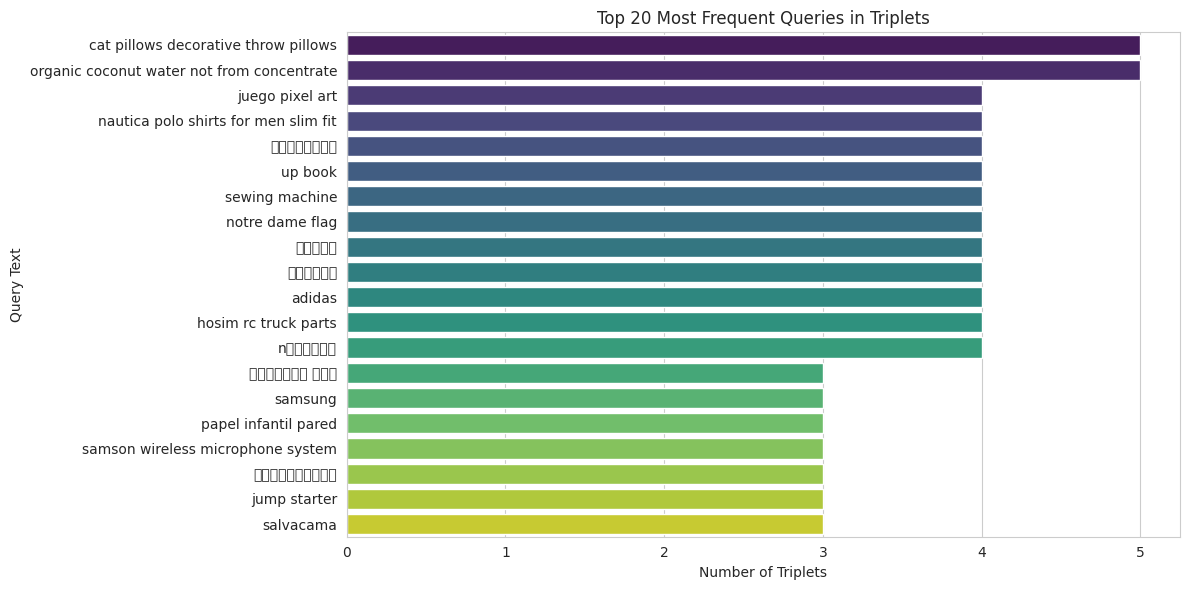

<ipython-input-6-03a6e461feed>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_counts.values, y=positive_counts.index, palette="magma", orient='h')
<ipython-input-6-03a6e461feed>:35: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:35: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:35: UserWarning: Glyph 12502 (\N{KATAKANA LETTER BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:35: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:35: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from fo

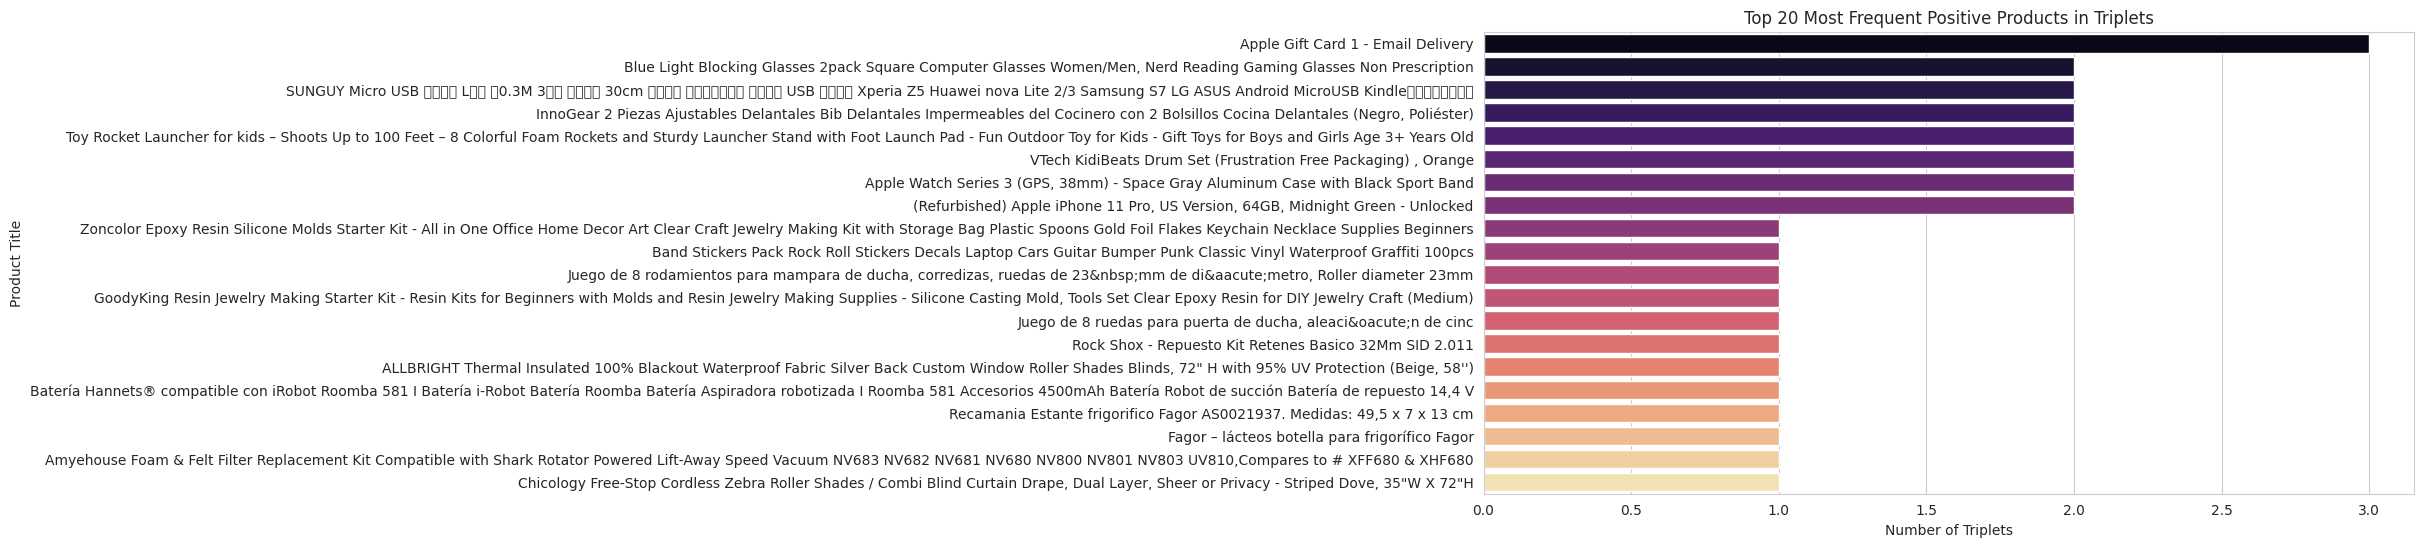

<ipython-input-6-03a6e461feed>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_counts.values, y=negative_counts.index, palette="plasma", orient='h')
<ipython-input-6-03a6e461feed>:45: UserWarning: Glyph 39764 (\N{CJK UNIFIED IDEOGRAPH-9B54}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:45: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:45: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:45: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-03a6e461feed>:45: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s

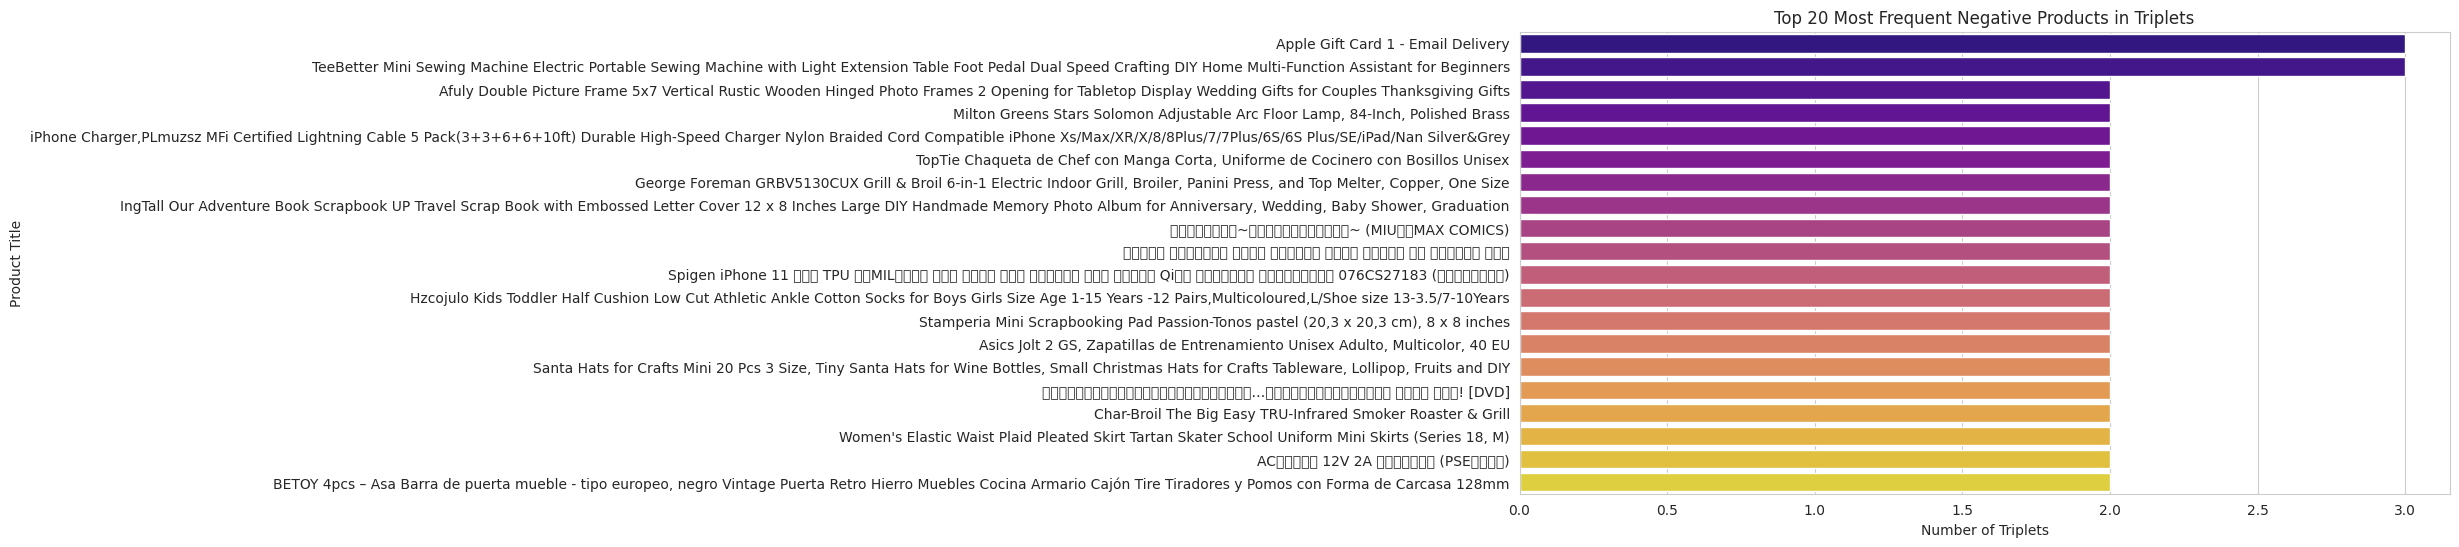


Calculating text lengths for distribution plots...


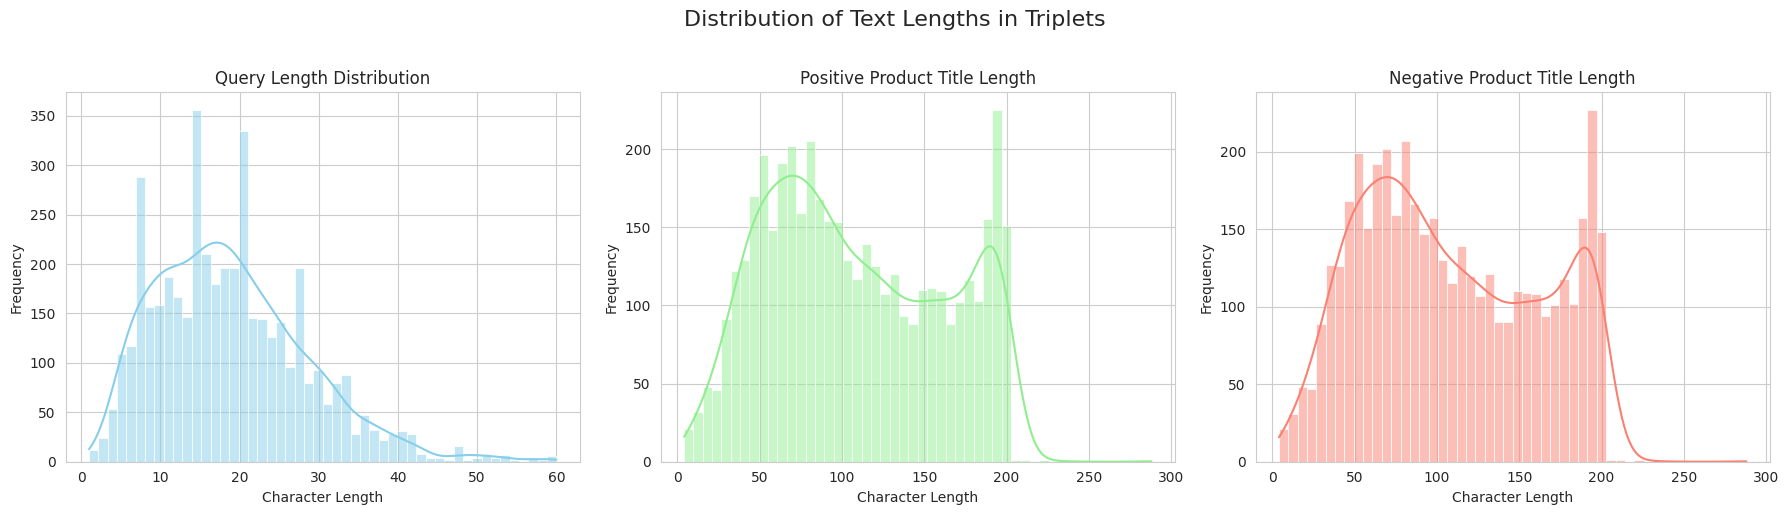


✅ Visualizations generated.


In [6]:
# ## Cell 4b: Visualize Training Triplets Data
# # Description: Create basic visualizations to understand the distribution
# # of queries, products, and text lengths in the generated triplets dataset.

import matplotlib.pyplot as plt
import seaborn as sns

print("Generating visualizations for the triplets dataset...")

# Set plot style
sns.set_style("whitegrid")

# Check if the DataFrame was created successfully in the previous cell
if 'triplets_df' in locals() and triplets_df is not None and not triplets_df.empty:

    # --- Visualization 1: Top N Most Frequent Queries ---
    plt.figure(figsize=(12, 6))
    top_n_queries = 20
    query_counts = triplets_df['query'].value_counts().head(top_n_queries)
    sns.barplot(x=query_counts.values, y=query_counts.index, palette="viridis", orient='h')
    plt.title(f'Top {top_n_queries} Most Frequent Queries in Triplets')
    plt.xlabel('Number of Triplets')
    plt.ylabel('Query Text')
    plt.tight_layout()
    plt.show()

    # --- Visualization 2: Top N Most Frequent Positive Products ---
    plt.figure(figsize=(12, 6))
    top_n_products = 20
    positive_counts = triplets_df['positive'].value_counts().head(top_n_products)
    sns.barplot(x=positive_counts.values, y=positive_counts.index, palette="magma", orient='h')
    plt.title(f'Top {top_n_products} Most Frequent Positive Products in Triplets')
    plt.xlabel('Number of Triplets')
    plt.ylabel('Product Title')
    plt.tight_layout()
    plt.show()

    # --- Visualization 3: Top N Most Frequent Negative Products ---
    plt.figure(figsize=(12, 6))
    negative_counts = triplets_df['negative'].value_counts().head(top_n_products)
    sns.barplot(x=negative_counts.values, y=negative_counts.index, palette="plasma", orient='h')
    plt.title(f'Top {top_n_products} Most Frequent Negative Products in Triplets')
    plt.xlabel('Number of Triplets')
    plt.ylabel('Product Title')
    plt.tight_layout()
    plt.show()

    # --- Visualization 4: Distribution of Text Lengths ---
    print("\nCalculating text lengths for distribution plots...")
    triplets_df['query_len'] = triplets_df['query'].str.len()
    triplets_df['positive_len'] = triplets_df['positive'].str.len()
    triplets_df['negative_len'] = triplets_df['negative'].str.len()

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(triplets_df['query_len'], bins=50, kde=True, color='skyblue')
    plt.title('Query Length Distribution')
    plt.xlabel('Character Length')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 2)
    sns.histplot(triplets_df['positive_len'], bins=50, kde=True, color='lightgreen')
    plt.title('Positive Product Title Length')
    plt.xlabel('Character Length')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 3)
    sns.histplot(triplets_df['negative_len'], bins=50, kde=True, color='salmon')
    plt.title('Negative Product Title Length')
    plt.xlabel('Character Length')
    plt.ylabel('Frequency')

    plt.suptitle('Distribution of Text Lengths in Triplets', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n✅ Visualizations generated.")

else:
    print("⚠️ Triplet DataFrame ('triplets_df') not available or empty. Skipping visualizations.")

In [7]:
## Good code
# # ## Cell 5: Train Bi-Encoder
# # # Description: Fine-tune a pre-trained Sentence Transformer model (Bi-Encoder) using the generated triplets.
# # # Uses TripletLoss, which aims to pull the anchor (query) and positive (relevant product) closer together
# # # in the embedding space, while pushing the anchor and negative (irrelevant product) further apart.

# # Proceed only if triplets were generated
# if train_triplets:
#     print("Training Bi-Encoder...")
#     # Initialize a pre-trained model
#     # You might need to adjust the model name based on availability and your needs
#     biencoder_model_name = "all-MiniLM-L6-v2"
#     print(f"Loading base Bi-Encoder model: {biencoder_model_name}")
#     biencoder = SentenceTransformer(biencoder_model_name)

#     # Create a DataLoader for the triplets
#     # Adjust batch_size based on your GPU memory
#     train_dataloader_bi = DataLoader(train_triplets, shuffle=True, batch_size=16)

#     # Define the Triplet loss function
#     train_loss_bi = losses.TripletLoss(model=biencoder)

#     # Train the model (adjust epochs, warmup_steps as needed)
#     # Using 1 epoch for demonstration purposes
#     NUM_EPOCHS_BI = 1
#     # Calculate warmup steps (e.g., 10% of training steps)
#     total_steps = len(train_dataloader_bi) * NUM_EPOCHS_BI
#     warmup_steps_bi = int(total_steps * 0.1)
#     print(f"Total training steps: {total_steps}, Warmup steps: {warmup_steps_bi}")

#     output_path_bi = "./biencoder-amazon-esci-trained"
#     print(f"Training for {NUM_EPOCHS_BI} epoch(s). Output path: {output_path_bi}")

#     start_time_train_bi = time.time()
#     biencoder.fit(train_objectives=[(train_dataloader_bi, train_loss_bi)],
#                   epochs=NUM_EPOCHS_BI,
#                   warmup_steps=warmup_steps_bi,
#                   show_progress_bar=True,
#                   output_path=output_path_bi,
#                   save_best_model=False # Set to True if using evaluation during training
#                  )
#     end_time_train_bi = time.time()
#     print(f"✅ Bi-Encoder training complete. Time taken: {end_time_train_bi - start_time_train_bi:.2f} seconds.")
# else:
#     print("❌ Skipping Bi-Encoder training as no training triplets were generated.")
#     biencoder = None # Ensure biencoder variable exists but is None if not trained

In [8]:
# ## Cell 5: Train Bi-Encoder with W&B Logging
# # Description: Fine-tune a pre-trained Sentence Transformer model (Bi-Encoder) using the generated triplets.
# # Uses TripletLoss and logs training progress to Weights & Biases using an API key from Colab secrets.

# Import necessary libraries for this cell
from sentence_transformers import SentenceTransformer, losses
from torch.utils.data import DataLoader
import time
import wandb # Import wandb
from google.colab import userdata # Import userdata for secrets

# Proceed only if triplets were generated
if 'train_triplets' in locals() and train_triplets:
    print("Training Bi-Encoder...")

    # --- W&B Login using Colab Secret ---
    print("Attempting to log in to Weights & Biases...")
    try:
        # Retrieve the API key from Colab secrets
        # Ensure you have a secret named 'wandb_api' in your Colab environment
        wandb_api_key = userdata.get('wandb_api')

        if wandb_api_key:
            # Log in to W&B non-interactively
            wandb.login(key=wandb_api_key)
            print("✅ Successfully logged into Weights & Biases.")
            # You can optionally initialize a run here for more control,
            # but sentence-transformers' fit often handles basic init.
            # wandb.init(project="your_project_name", name="bi-encoder-finetune")
        else:
            print("⚠️ W&B API key not found in Colab secrets (secret name: 'wandb_api'). Skipping W&B logging.")
            wandb_api_key = None # Ensure it's None if not found

    except ImportError:
        print("⚠️ `google.colab.userdata` not available. Are you running in Colab? Skipping W&B login.")
        wandb_api_key = None
    except Exception as e:
        print(f"❌ Error during W&B login: {e}. Skipping W&B logging.")
        wandb_api_key = None
    # --- End of W&B Login ---


    # Initialize a pre-trained model
    biencoder_model_name = "all-MiniLM-L6-v2"
    print(f"Loading base Bi-Encoder model: {biencoder_model_name}")
    biencoder = SentenceTransformer(biencoder_model_name)

    # Create a DataLoader for the triplets
    train_dataloader_bi = DataLoader(train_triplets, shuffle=True, batch_size=16)

    # Define the Triplet loss function
    train_loss_bi = losses.TripletLoss(model=biencoder)

    # Train the model parameters
    NUM_EPOCHS_BI = 1
    total_steps = len(train_dataloader_bi) * NUM_EPOCHS_BI
    warmup_steps_bi = int(total_steps * 0.1)
    output_path_bi = "./biencoder-amazon-esci-trained" # Also used as default run name by fit if not set otherwise

    print(f"Total training steps: {total_steps}, Warmup steps: {warmup_steps_bi}")
    print(f"Training for {NUM_EPOCHS_BI} epoch(s). Output path: {output_path_bi}")

    start_time_train_bi = time.time()

    # The 'fit' method automatically uses wandb if it's installed and logged in.
    # It will create a run named after output_path_bi by default.
    biencoder.fit(train_objectives=[(train_dataloader_bi, train_loss_bi)],
                  epochs=NUM_EPOCHS_BI,
                  warmup_steps=warmup_steps_bi,
                  show_progress_bar=True,
                  output_path=output_path_bi,
                  save_best_model=False, # Set to True if using evaluation during training
                  # Note: wandb integration is implicit if wandb.login() succeeded
                 )

    end_time_train_bi = time.time()
    print(f"✅ Bi-Encoder training complete. Time taken: {end_time_train_bi - start_time_train_bi:.2f} seconds.")

    # --- Finish W&B Run (Optional but recommended) ---
    if wandb_api_key and wandb.run is not None:
         print("Finishing W&B run...")
         wandb.finish()
         print("✅ W&B run finished.")
    # --- End of W&B Finish ---

else:
    print("❌ Skipping Bi-Encoder training as no training triplets were generated.")
    biencoder = None # Ensure biencoder variable exists but is None if not trained

Training Bi-Encoder...
Attempting to log in to Weights & Biases...


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: navneetkrch (navneetkrch-samsung-research) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Successfully logged into Weights & Biases.
Loading base Bi-Encoder model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss


✅ Bi-Encoder training complete. Time taken: 30.15 seconds.
Finishing W&B run...


train/epoch,▁
train/global_step,▁
total_flos,0
train/epoch,1
train/global_step,277
train_loss,5.00968
train_runtime,28.2591
train_samples_per_second,156.693
train_steps_per_second,9.802


✅ W&B run finished.


In [9]:
# ## Cell 6: Prepare Cross-Encoder Training Data (Pairs)
# ... (description) ...

print("Preparing Cross-Encoder training data (pairs) from merged data...")
CROSS_ENCODER_SAMPLE_SIZE = 20000
TARGET_LABELS_CROSS = ['E', 'I']

# Check if merged data loaded successfully
if merged_train_df is not None and not merged_train_df.empty:
    # Filter the merged DataFrame for 'E' and 'I' labels
    print(f"Filtering merged data for relevant examples ({TARGET_LABELS_CROSS})...")
    # Ensure 'esci_label' column exists
    if 'esci_label' in merged_train_df.columns:
        relevant_df_cross = merged_train_df[merged_train_df['esci_label'].isin(TARGET_LABELS_CROSS)].copy()
        print(f"Found {len(relevant_df_cross)} examples with labels 'E' or 'I' in merged data.")

        # Sample if needed
        if len(relevant_df_cross) > CROSS_ENCODER_SAMPLE_SIZE:
            print(f"Sampling {CROSS_ENCODER_SAMPLE_SIZE} examples for Cross-Encoder training...")
            cross_df_sampled = relevant_df_cross.sample(n=CROSS_ENCODER_SAMPLE_SIZE, random_state=42)
        elif len(relevant_df_cross) > 0:
            print(f"Using all {len(relevant_df_cross)} 'E'/'I' examples (less than or equal to sample size).")
            cross_df_sampled = relevant_df_cross
        else:
            print("⚠️ No relevant ('E'/'I') examples found in merged data for Cross-Encoder training.")
            cross_df_sampled = None

        # Create InputExamples if sampling was successful
        if cross_df_sampled is not None and not cross_df_sampled.empty:
            print("Creating InputExamples for Cross-Encoder...")
            crossencoder_train_data = []
            # Iterate through the sampled DataFrame rows
            for index, row in cross_df_sampled.iterrows():
                 # Basic check for valid text data
                 if isinstance(row["query"], str) and isinstance(row["product_title"], str):
                      label = 1.0 if row["esci_label"] == "E" else 0.0
                      crossencoder_train_data.append(InputExample(texts=[row["query"], row["product_title"]], label=label))

            train_dataset_cross = crossencoder_train_data # DataLoader handles list directly
            print(f"✅ Prepared {len(train_dataset_cross)} pairs for Cross-Encoder training from merged data.")
        else:
            train_dataset_cross = []
            print("❌ Skipping Cross-Encoder training data preparation as no relevant samples were found/selected from merged data.")
    else:
        train_dataset_cross = []
        print("❌ 'esci_label' column not found in merged data. Cannot filter for Cross-Encoder examples.")

else:
    print("❌ Merged training DataFrame ('merged_train_df') not found or empty. Skipping Cross-Encoder data preparation.")
    train_dataset_cross = []

Preparing Cross-Encoder training data (pairs) from merged data...
Filtering merged data for relevant examples (['E', 'I'])...
Found 1397348 examples with labels 'E' or 'I' in merged data.
Sampling 20000 examples for Cross-Encoder training...
Creating InputExamples for Cross-Encoder...
✅ Prepared 20000 pairs for Cross-Encoder training from merged data.


In [10]:
# ## Cell 7: Train Cross-Encoder
# # Description: Fine-tune a pre-trained Cross-Encoder model using the prepared query-product pairs and labels.
# # Cross-Encoders take both inputs simultaneously and output a similarity score, often achieving higher accuracy
# # than Bi-Encoders but are much slower for inference over large candidate sets.

# Proceed only if training data was prepared
if train_dataset_cross:
    print("Training Cross-Encoder...")
    # Initialize a pre-trained Cross-Encoder model. num_labels=1 for regression-style similarity (0.0 to 1.0)
    crossencoder_model_name = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
    print(f"Loading base Cross-Encoder model: {crossencoder_model_name}")
    # Set max_length appropriate for your data, helps prevent memory issues
    crossencoder = CrossEncoder(crossencoder_model_name, num_labels=1, max_length=128)

    # Create a DataLoader
    # Adjust batch_size based on GPU memory
    train_dataloader_cross = DataLoader(train_dataset_cross, batch_size=16, shuffle=True)

    # Train the model (adjust epochs, warmup_steps as needed)
    NUM_EPOCHS_CROSS = 1
    # Calculate warmup steps (e.g., 10% of training steps)
    total_steps_cross = len(train_dataloader_cross) * NUM_EPOCHS_CROSS
    warmup_steps_cross = int(total_steps_cross * 0.1)
    print(f"Total training steps: {total_steps_cross}, Warmup steps: {warmup_steps_cross}")


    output_path_cross = "./crossencoder-amazon-esci-trained"
    print(f"Training for {NUM_EPOCHS_CROSS} epoch(s). Output path: {output_path_cross}")

    start_time_train_cross = time.time()
    crossencoder.fit(
        train_dataloader=train_dataloader_cross,
        epochs=NUM_EPOCHS_CROSS,
        warmup_steps=warmup_steps_cross,
        show_progress_bar=True,
        output_path=output_path_cross # Save intermediate checkpoints
    )
    end_time_train_cross = time.time()
    print(f"✅ Cross-Encoder training complete. Time taken: {end_time_train_cross - start_time_train_cross:.2f} seconds.")
else:
    print("❌ Skipping Cross-Encoder training as no training data was prepared.")
    crossencoder = None # Ensure crossencoder variable exists but is None if not trained

Training Cross-Encoder...
Loading base Cross-Encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Total training steps: 1250, Warmup steps: 125
Training for 1 epoch(s). Output path: ./crossencoder-amazon-esci-trained


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/1250 [00:00<?, ?it/s]

✅ Cross-Encoder training complete. Time taken: 49.56 seconds.


In [11]:
# ## Cell 8: Load and Prepare Test Data
# # Description: Load the 'test' split of the dataset for evaluation.
# # Merge queries and products based on product_id and locale to get query-product pairs with labels.
# # Sample the test set for faster evaluation during development.

print("Loading and preparing test data...")
try:
    # Load test splits
    queries_test = load_dataset("milistu/amazon-esci-data", "queries", split="test")
    products_test = load_dataset("milistu/amazon-esci-data", "products", split="test")

    # Convert to pandas
    queries_test_df = queries_test.to_pandas()
    products_test_df = products_test.to_pandas()

    # Merge on product_id and locale
    # Using 'inner' merge ensures we only keep products that appear with a query in the test set
    print("Merging test queries and products...")
    merged_test_df = pd.merge(queries_test_df, products_test_df, on=["product_id", "product_locale"], how="inner")
    print(f"Full merged test set size: {len(merged_test_df)}")

    # --- Optional: Sample the test data for faster evaluation ---
    EVAL_SAMPLE_SIZE = 1000 # Number of query-product pairs to evaluate on
    if 0 < EVAL_SAMPLE_SIZE < len(merged_test_df):
         print(f"Sampling {EVAL_SAMPLE_SIZE} examples from the test set for evaluation...")
         test_sample_df = merged_test_df.sample(n=EVAL_SAMPLE_SIZE, random_state=42)
    else:
         print(f"Using the full test set ({len(merged_test_df)} examples) for evaluation.")
         test_sample_df = merged_test_df

    print(f"Using {len(test_sample_df)} samples for evaluation.")
    print("✅ Test data prepared.")

except Exception as e:
    print(f"❌ Error loading or preparing test data: {e}")
    test_sample_df = None # Indicate failure

Loading and preparing test data...
Merging test queries and products...
Full merged test set size: 488077
Sampling 1000 examples from the test set for evaluation...
Using 1000 samples for evaluation.
✅ Test data prepared.


In [12]:
# ## Cell 9: Define Evaluation Metric (MRR@k for Bi-Encoder)
# # Description: Define a function to calculate Mean Reciprocal Rank at k (MRR@k).
# # This metric evaluates how highly the first relevant item ('E' label) is ranked for a given query
# # based *only* on the Bi-Encoder's scores.

print("Defining MRR@k evaluation function for Bi-Encoder...")

def evaluate_mrr_bi_encoder(test_data_records, bi_encoder_model, k=3):
    """
    Calculates MRR@k based *only* on Bi-Encoder scores.
    Assumes test_data_records is a list of dictionaries, each with 'query', 'product_title', 'esci_label'.
    """
    if not test_data_records:
        print("⚠️ No test data provided for evaluation.")
        return 0.0
    if bi_encoder_model is None:
        print("⚠️ Bi-encoder model is not available for evaluation.")
        return 0.0

    mrr_scores = []
    queries = defaultdict(list) # Group items by query

    # Group records by query
    print("Grouping test records by query...")
    for record in test_data_records:
        # Basic check for necessary keys
        if "query" in record and "product_title" in record and "esci_label" in record:
             queries[record["query"]].append(record)
        # else: # Optional: Log skipped records
        #      print(f"Skipping record due to missing keys: {record}")


    num_queries_total = len(queries)
    print(f"Evaluating MRR@{k} for {num_queries_total} unique queries...")
    processed_queries = 0
    start_time_eval = time.time()

    for query_text, items in queries.items():
        # Get all product titles for the current query
        candidates = [item["product_title"] for item in items if isinstance(item.get("product_title"), str)] # Ensure titles are strings

        # Skip if no valid candidates for this query
        if not candidates:
            continue

        try:
            # Encode query and candidates using the Bi-Encoder
            # Ensure model is on the correct device (CPU or GPU)
            query_embedding = bi_encoder_model.encode(query_text, convert_to_tensor=True, show_progress_bar=False)
            # Handle potential large number of candidates - encode in batches if needed (though usually fine for evaluation samples)
            candidate_embeddings = bi_encoder_model.encode(candidates, convert_to_tensor=True, show_progress_bar=False)

            # Calculate cosine similarity scores (or dot product if embeddings are normalized)
            # Using dot product assuming normalized embeddings from common SBERT models
            scores = np.dot(candidate_embeddings.cpu().numpy(), query_embedding.cpu().numpy().T).flatten()

            # Combine items with their scores and rank them (highest score first)
            # Only include items that had a valid title initially
            valid_items = [item for item in items if isinstance(item.get("product_title"), str)]
            ranked_items = sorted(zip(valid_items, scores), key=lambda x: x[1], reverse=True)

            # Find the rank of the first relevant item ('E' label)
            reciprocal_rank = 0.0
            # Iterate up to k or the number of ranked items, whichever is smaller
            for rank, (item, score) in enumerate(ranked_items[:k]):
                # IMPORTANT: Check against the actual label 'E' in the dataset
                if item["esci_label"] == "E":
                    # Rank is 0-based, so add 1 for MRR calculation
                    reciprocal_rank = 1 / (rank + 1)
                    break # Found the first relevant item within top k

            mrr_scores.append(reciprocal_rank) # Append 0.0 if no relevant item found in top k

        except Exception as e:
             print(f"⚠️ Error processing query '{query_text}': {e}")
             # Optionally append 0.0 or skip this query's score
             mrr_scores.append(0.0)


        processed_queries += 1
        if processed_queries % 100 == 0 or processed_queries == num_queries_total: # Print progress
             current_time = time.time()
             elapsed = current_time - start_time_eval
             print(f"  Processed {processed_queries}/{num_queries_total} queries... (Elapsed: {elapsed:.2f}s)")

    # Calculate the mean MRR score
    mean_mrr = np.mean(mrr_scores) if mrr_scores else 0.0
    print(f"Finished MRR calculation for {len(mrr_scores)} queries.")
    return mean_mrr

print("✅ MRR@k function defined.")

Defining MRR@k evaluation function for Bi-Encoder...
✅ MRR@k function defined.


In [13]:
# ## Cell 10: Run Evaluation
# # Description: Evaluate the trained Bi-Encoder using the MRR@k metric on the (sampled) test set.
# # Note: This uses the Bi-Encoder trained in Cell 5 (if training occurred).

print("Running evaluation...")

# Check if test data and model are available
if test_sample_df is not None and biencoder is not None:
    # Convert the test sample DataFrame to a list of dictionaries for the function
    print(f"Converting {len(test_sample_df)} test samples to records...")
    test_records = test_sample_df.to_dict("records")

    # Set k for MRR@k
    K_VALUE = 3
    print(f"Calculating MRR@{K_VALUE} using the fine-tuned Bi-Encoder...")

    # Evaluate the FINE-TUNED Bi-Encoder
    mrr_score_bi = evaluate_mrr_bi_encoder(test_records, biencoder, k=K_VALUE) # Pass the trained biencoder

    print(f"✅ Bi-Encoder MRR@{K_VALUE}: {mrr_score_bi:.4f}")
    # --- Placeholder for Cross-Encoder Evaluation ---
    # Evaluating Cross-Encoder typically involves:
    # 1. Using the Bi-Encoder to retrieve a larger set of candidates (e.g., top 50).
    # 2. Using the Cross-Encoder to re-rank these candidates.
    # 3. Calculating MRR based on the re-ranked list.
    # This is more complex and not implemented in the provided `evaluate_mrr` function.
    print("(Cross-Encoder evaluation would require a separate re-ranking step and function)")
elif test_sample_df is None:
     print("❌ Cannot run evaluation because test data failed to load/prepare.")
elif biencoder is None:
     print("❌ Cannot run evaluation because the Bi-Encoder model was not trained/loaded.")

Running evaluation...
Converting 1000 test samples to records...
Calculating MRR@3 using the fine-tuned Bi-Encoder...
Grouping test records by query...
Evaluating MRR@3 for 980 unique queries...
  Processed 100/980 queries... (Elapsed: 1.50s)
  Processed 200/980 queries... (Elapsed: 2.95s)
  Processed 300/980 queries... (Elapsed: 4.37s)
  Processed 400/980 queries... (Elapsed: 6.24s)
  Processed 500/980 queries... (Elapsed: 8.38s)
  Processed 600/980 queries... (Elapsed: 9.79s)
  Processed 700/980 queries... (Elapsed: 11.25s)
  Processed 800/980 queries... (Elapsed: 12.68s)
  Processed 900/980 queries... (Elapsed: 14.10s)
  Processed 980/980 queries... (Elapsed: 15.25s)
Finished MRR calculation for 980 queries.
✅ Bi-Encoder MRR@3: 0.6128
(Cross-Encoder evaluation would require a separate re-ranking step and function)


In [14]:
# ## Cell 11: Save Final Models (Optional)
# # Description: Save the fine-tuned Bi-Encoder and Cross-Encoder models to disk if they were trained.

print("Saving final models (if trained)...")
# Use the paths defined during training or choose new ones
biencoder_save_path = "./biencoder-amazon-esci-final"
crossencoder_save_path = "./crossencoder-amazon-esci-final"

model_saved = False
if 'biencoder' in locals() and biencoder is not None:
    try:
        biencoder.save(biencoder_save_path)
        print(f"✅ Bi-Encoder saved to {biencoder_save_path}")
        model_saved = True
    except Exception as e:
        print(f"❌ Error saving Bi-Encoder: {e}")

if 'crossencoder' in locals() and crossencoder is not None:
     try:
        crossencoder.save(crossencoder_save_path)
        print(f"✅ Cross-Encoder saved to {crossencoder_save_path}")
        model_saved = True
     except Exception as e:
        print(f"❌ Error saving Cross-Encoder: {e}")


if not model_saved:
    print("No models were trained or available to save.")

Saving final models (if trained)...
✅ Bi-Encoder saved to ./biencoder-amazon-esci-final
✅ Cross-Encoder saved to ./crossencoder-amazon-esci-final


In [15]:
# ## Cell 12: Streamlit App - Installations
# # Description: Install libraries required specifically for the Streamlit application and tunneling.

print("Installing Streamlit dependencies...")
!pip install -q streamlit pyngrok
print("✅ Streamlit dependencies installed.")

Installing Streamlit dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.8 MB/s eta 0:00:00
✅ Streamlit dependencies installed.


In [16]:
# ## Cell 13: Streamlit App - Write app.py
# # Description: Write the Python script for the Streamlit web application.
# # This version can load fine-tuned or base models and demonstrates ranking differences
# # on a sample of queries loaded dynamically from the test set.

%%writefile app.py
import streamlit as st
from sentence_transformers import SentenceTransformer, CrossEncoder
import pandas as pd
import numpy as np
from datasets import load_dataset
import time # To measure time
import os # To check model paths

# --- Configuration ---
# Set paths for models. Fallback to base models if fine-tuned ones don't exist.
BI_ENCODER_FINAL_PATH = "./biencoder-amazon-esci-final"
CROSS_ENCODER_FINAL_PATH = "./crossencoder-amazon-esci-final"
BASE_BI_ENCODER = "all-MiniLM-L6-v2"
BASE_CROSS_ENCODER = "cross-encoder/ms-marco-MiniLM-L-6-v2"

# Determine which model paths to use
bi_encoder_path_to_load = BI_ENCODER_FINAL_PATH if os.path.exists(BI_ENCODER_FINAL_PATH) else BASE_BI_ENCODER
cross_encoder_path_to_load = CROSS_ENCODER_FINAL_PATH if os.path.exists(CROSS_ENCODER_FINAL_PATH) else BASE_CROSS_ENCODER

NUM_QUERIES_TO_LOAD = 200 # How many unique queries to sample for the dropdown
MIN_PRODUCTS_PER_QUERY = 5 # Minimum products needed for a query to be included
MAX_CANDIDATES_TO_RANK = 10 # Max products to show/rank per query in the app
TOP_N_TO_DISPLAY = 5 # How many top results to show

# --- Caching Functions ---
# Cache data loading to avoid reloading on every interaction
@st.cache_data(ttl=3600) # Cache for 1 hour
def load_test_data_for_app(num_queries, min_products):
    st.info(f"Loading and preparing test data ({num_queries} queries, min {min_products} products)...")
    try:
        # Use huggingface datasets library directly for potentially large data
        queries_ds = load_dataset("milistu/amazon-esci-data", "queries", split="test")
        products_ds = load_dataset("milistu/amazon-esci-data", "products", split="test")

        # Convert to pandas for merging and manipulation
        queries = queries_ds.to_pandas()
        products = products_ds.to_pandas()

        # Ensure required columns exist before merge
        if not all(col in queries.columns for col in ["query", "product_id", "product_locale"]):
            st.error("Queries data is missing required columns ('query', 'product_id', 'product_locale').")
            return pd.DataFrame(columns=['query', 'product_title'])
        if not all(col in products.columns for col in ["product_title", "product_id", "product_locale"]):
            st.error("Products data is missing required columns ('product_title', 'product_id', 'product_locale').")
            return pd.DataFrame(columns=['query', 'product_title'])

        merged = pd.merge(queries, products, on=["product_id", "product_locale"], how="inner")

        # Group by query to get unique product titles per query
        st.write("Grouping products by query...") # Show progress in app
        grouped = (
            merged.groupby("query")["product_title"]
            .apply(lambda x: list(pd.unique(x))) # Use pd.unique for deduplication
            .reset_index()
        )

        # Filter queries with enough products
        grouped["product_count"] = grouped["product_title"].apply(len)
        filtered = grouped[grouped["product_count"] >= min_products].reset_index(drop=True)
        st.write(f"Found {len(filtered)} queries with at least {min_products} products.")

        # Sample queries if needed
        if len(filtered) > num_queries:
            st.write(f"Sampling {num_queries} queries for the dropdown...")
            return filtered.sample(n=num_queries, random_state=42)
        elif not filtered.empty:
             return filtered
        else:
             st.warning("No queries found matching the criteria after loading.")
             return pd.DataFrame(columns=['query', 'product_title']) # Return empty df

    except Exception as e:
        st.error(f"Error loading data: {e}")
        return pd.DataFrame(columns=['query', 'product_title']) # Return empty df

# Cache model loading - use @st.cache_resource for models
@st.cache_resource
def load_models(bi_path, cross_path):
    st.info(f"Loading Bi-Encoder from: {bi_path}")
    st.info(f"Loading Cross-Encoder from: {cross_path}")
    try:
        bi = SentenceTransformer(bi_path)
        cross = CrossEncoder(cross_path)
        st.success("Models loaded successfully!")
        return bi, cross
    except Exception as e:
        st.error(f"Error loading models: {e}")
        return None, None

# --- Main App Logic ---
st.set_page_config(layout="wide")
st.title("🔍 Bi-Encoder vs Cross-Encoder Ranking Demo")
st.markdown(f"""
Comparing rankings using:
- **Bi-Encoder:** `{bi_encoder_path_to_load}`
- **Cross-Encoder:** `{cross_encoder_path_to_load}`
""")
st.caption(f"App will load up to {NUM_QUERIES_TO_LOAD} unique queries from the test set having at least {MIN_PRODUCTS_PER_QUERY} products.")

# Load data and models
valid_queries_df = load_test_data_for_app(NUM_QUERIES_TO_LOAD, MIN_PRODUCTS_PER_QUERY)
bi_model, cross_model = load_models(bi_encoder_path_to_load, cross_encoder_path_to_load)

if bi_model is None or cross_model is None:
    st.error("Models failed to load. Cannot proceed.")
    st.stop() # Stop execution if models failed to load

if not valid_queries_df.empty:
    # --- Query Selection ---
    query_list = [""] + sorted(valid_queries_df["query"].tolist()) # Add empty option
    selected_query = st.selectbox("Choose a sample query:", query_list)

    if selected_query: # Proceed only if a query is selected
        query_row = valid_queries_df[valid_queries_df["query"] == selected_query]

        if not query_row.empty:
            all_candidates = query_row.iloc[0]["product_title"]
            # Limit candidates for performance and display
            candidates_to_rank = all_candidates[:MAX_CANDIDATES_TO_RANK]

            st.markdown(f"---")
            st.subheader(f"Ranking Top {len(candidates_to_rank)} Candidates for:")
            st.markdown(f"> **{selected_query}**")
            st.markdown(f"---")


            col1, col2 = st.columns(2)

            with col1:
                # --- Bi-Encoder Ranking ---
                st.markdown("### 🔹 Bi-Encoder Ranking")
                with st.spinner("Running Bi-Encoder..."):
                    start_time_bi = time.time()
                    try:
                        query_embedding = bi_model.encode(selected_query, convert_to_tensor=True, show_progress_bar=False)
                        candidate_embeddings = bi_model.encode(candidates_to_rank, convert_to_tensor=True, show_progress_bar=False)
                        scores_bi = np.dot(candidate_embeddings.cpu().numpy(), query_embedding.cpu().numpy().T).flatten()
                        ranked_bi = sorted(zip(candidates_to_rank, scores_bi), key=lambda x: x[1], reverse=True)
                    except Exception as e:
                         st.error(f"Bi-Encoder Error: {e}")
                         ranked_bi = [] # Clear results on error
                    end_time_bi = time.time()

                if ranked_bi:
                    for i, (title, score) in enumerate(ranked_bi[:TOP_N_TO_DISPLAY]):
                        st.markdown(f"{i+1}. **{title}** — Score: `{score:.4f}`")
                    st.caption(f"Time: {end_time_bi - start_time_bi:.4f}s")
                else:
                     st.write("No results from Bi-Encoder.")


            with col2:
                # --- Cross-Encoder Ranking ---
                st.markdown("### 🔸 Cross-Encoder Re-ranking")
                with st.spinner("Running Cross-Encoder..."):
                    start_time_cross = time.time()
                    try:
                        cross_inputs = [[selected_query, c] for c in candidates_to_rank]
                        # Use predict for CrossEncoder, handles batching internally if needed
                        scores_cross = cross_model.predict(cross_inputs, show_progress_bar=False, convert_to_numpy=True) # Ensure numpy output
                        ranked_cross = sorted(zip(candidates_to_rank, scores_cross), key=lambda x: x[1], reverse=True)
                    except Exception as e:
                         st.error(f"Cross-Encoder Error: {e}")
                         ranked_cross = [] # Clear results on error
                    end_time_cross = time.time()

                if ranked_cross:
                    for i, (title, score) in enumerate(ranked_cross[:TOP_N_TO_DISPLAY]):
                        st.markdown(f"{i+1}. **{title}** — Score: `{score:.4f}`")
                    st.caption(f"Time: {end_time_cross - start_time_cross:.4f}s")
                else:
                     st.write("No results from Cross-Encoder.")

        else:
            # Should not happen if query is selected from the list, but good to have a check
            st.error("Could not find data for the selected query (this should not happen).")
    else:
        st.info("⬆️ Select a query from the dropdown above to see the ranking comparison.")
else:
    st.error("Failed to load any valid queries for the application. Please check data loading steps (Cell 8) and the dataset.")
    st.info("Ensure the 'milistu/amazon-esci-data' dataset exists and is accessible.")


print("✅ Streamlit app script (app.py) written.")

Writing app.py


In [17]:
# ## Cell 14: Run Streamlit App with ngrok Tunneling
# # Description: Use pyngrok to create a public URL tunnel to the Streamlit app running locally (or on Colab/remote server).
# # Make sure you have set your ngrok authentication token (e.g., via Colab secrets or environment variable).

print("Setting up ngrok tunnel and running Streamlit app...")
from pyngrok import ngrok, conf
import os
import getpass # To hide token input if necessary

# --- Ngrok Authentication ---
ngrok_token = None
try:
    # Try getting token from Colab secrets first (preferred)
    from google.colab import userdata
    ngrok_token = userdata.get('NGROK_AUTH_TOKEN')
    if ngrok_token:
        print("Using ngrok token from Colab secrets.")
except ImportError:
    # Fallback to environment variable if not in Colab
    print("Not in Colab or 'userdata' unavailable, checking environment variable...")
    ngrok_token = os.environ.get("NGROK_AUTH_TOKEN")
    if ngrok_token:
        print("Using ngrok token from environment variable.")

# If token still not found, prompt the user (optional, less secure)
# if not ngrok_token:
#     print("Ngrok token not found in secrets or environment.")
#     ngrok_token = getpass.getpass("Enter your ngrok authentication token (will not be shown): ")
#     if ngrok_token:
#          print("Using ngrok token provided via prompt.")
#     else:
#          print("⚠️ No ngrok token provided. Tunnel functionality might be limited or fail.")


# Set auth token if found
if ngrok_token:
     try:
          ngrok.set_auth_token(ngrok_token)
          print("Ngrok token set successfully.")
     except Exception as e:
          print(f"⚠️ Error setting ngrok token: {e}")
else:
     print("⚠️ No ngrok auth token found or provided.")


# --- Kill any existing ngrok tunnels to avoid conflicts ---
# This might require ngrok process to be running, handle errors gracefully
try:
    print("Attempting to close existing ngrok tunnels...")
    all_tunnels = ngrok.get_tunnels()
    if all_tunnels:
        for tunnel in all_tunnels:
            ngrok.disconnect(tunnel.public_url)
        print("Existing tunnels closed.")
    else:
        print("No existing ngrok tunnels found.")
except Exception as e:
    # Errors commonly happen if ngrok process isn't running - often safe to ignore
    print(f"Info: Could not query/close existing ngrok tunnels (often okay): {e}")


# --- Start Streamlit and ngrok ---
# Run Streamlit in the background on the default port 8501
# Using --server.enableCORS=false can sometimes help with connection issues behind proxies
# Using --server.headless=true prevents browser opening automatically if running locally
print("Starting Streamlit app in background...")
os.system('streamlit run app.py --server.port 8501 --server.headless true &') # Use os.system for background process
time.sleep(5) # Give streamlit a moment to start up

# Configure ngrok region if needed (e.g., 'us', 'eu', 'ap', 'au', 'sa', 'jp', 'in')
# conf.get_default().region = 'us'

# Start the ngrok tunnel to port 8501
try:
    print("Starting ngrok tunnel...")
    public_url = ngrok.connect(8501, "http") # Connect to the Streamlit port
    print(" Tunnel details:", public_url)
    print(f"✅ Streamlit app is publicly accessible at: {public_url.public_url}") # Use public_url attribute
except Exception as e:
    print(f"❌ Failed to start ngrok tunnel: {e}")
    print("  Troubleshooting tips:")
    print("  - Ensure ngrok is installed and authenticated correctly (check token).")
    print("  - Check if another process is already using port 8501.")
    print("  - Verify your internet connection and firewall settings.")
    print("  - Try specifying an ngrok region if connection times out.")

# The Streamlit app will now run in the background. Access it via the public_url.
# To stop: Interrupt/restart the kernel or manually kill the 'streamlit' and 'ngrok' processes.

Setting up ngrok tunnel and running Streamlit app...
Using ngrok token from Colab secrets.
Ngrok token set successfully.
Attempting to close existing ngrok tunnels...
No existing ngrok tunnels found.
Starting Streamlit app in background...
Starting ngrok tunnel...
 Tunnel details: NgrokTunnel: "https://40f5-34-147-24-162.ngrok-free.app" -> "http://localhost:8501"
✅ Streamlit app is publicly accessible at: https://40f5-34-147-24-162.ngrok-free.app


# Claude Version

In [18]:
## Cell 1: Setup and Environment
# Install required packages
!pip install -q sentence-transformers datasets pandas streamlit pyngrok wandb
!pip install -q gcsfs==2023.6.0 fsspec==2023.6.0 # Pin specific versions to avoid conflicts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.0 MB/s eta 0:00:00


In [19]:
## Cell 2: Import Libraries
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset
from typing import List, Dict, Tuple, Union
import torch

# Import sentence-transformers modules
from sentence_transformers import SentenceTransformer, InputExample, losses, util
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CECorrelationEvaluator

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


In [20]:
## Cell 3: Load Amazon ESCI Dataset (Queries and Products)
# Load the Amazon ESCI dataset from Hugging Face Hub
print("Loading the Amazon ESCI dataset...")
queries_train = load_dataset("milistu/amazon-esci-data", name="queries", split="train")
products_train = load_dataset("milistu/amazon-esci-data", name="products", split="train")

print(f"Loaded {len(queries_train)} query examples and {len(products_train)} product examples")

# Display sample of the data to understand its structure
print("\nSample query data:")
print(queries_train.features)
print(queries_train[:2])

print("\nSample product data:")
print(products_train.features)
print(products_train[:2])

Loading the Amazon ESCI dataset...
Loaded 1983272 query examples and 1371823 product examples

Sample query data:
{'example_id': Value(dtype='int64', id=None), 'query': Value(dtype='string', id=None), 'query_id': Value(dtype='int64', id=None), 'product_id': Value(dtype='string', id=None), 'product_locale': Value(dtype='string', id=None), 'esci_label': Value(dtype='string', id=None), 'small_version': Value(dtype='int64', id=None), 'large_version': Value(dtype='int64', id=None), 'split': Value(dtype='string', id=None), '__index_level_0__': Value(dtype='int64', id=None)}
{'example_id': [0, 1], 'query': [' revent 80 cfm', ' revent 80 cfm'], 'query_id': [0, 0], 'product_id': ['B000MOO21W', 'B07X3Y6B1V'], 'product_locale': ['us', 'us'], 'esci_label': ['I', 'E'], 'small_version': [0, 0], 'large_version': [1, 1], 'split': ['train', 'train'], '__index_level_0__': [0, 1]}

Sample product data:
{'product_id': Value(dtype='string', id=None), 'product_title': Value(dtype='string', id=None), 'produc

In [21]:
## Cell 4: Convert to Pandas DataFrames and Merge
# Convert to pandas DataFrames for easier manipulation
queries_df = pd.DataFrame(queries_train)
products_df = pd.DataFrame(products_train)

# Merge queries with products to get full information
train_data = pd.merge(
    queries_df,
    products_df,
    on=['product_id', 'product_locale'],
    how='inner'
)

print(f"\nMerged training data: {len(train_data)} query-product pairs")

# Define ESCI labels meaning
print("\nESCI Labels:")
print("E: Exact (most relevant)")
print("S: Substitute (somewhat relevant)")
print("C: Complement (complementary products)")
print("I: Irrelevant")

# Display DataFrame info
print("\nDataFrame Information:")
print(train_data.info())



Merged training data: 1834619 query-product pairs

ESCI Labels:
E: Exact (most relevant)
S: Substitute (somewhat relevant)
C: Complement (complementary products)
I: Irrelevant

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834619 entries, 0 to 1834618
Data columns (total 17 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   example_id            int64 
 1   query                 object
 2   query_id              int64 
 3   product_id            object
 4   product_locale        object
 5   esci_label            object
 6   small_version         int64 
 7   large_version         int64 
 8   split_x               object
 9   __index_level_0___x   int64 
 10  product_title         object
 11  product_description   object
 12  product_bullet_point  object
 13  product_brand         object
 14  product_color         object
 15  split_y               object
 16  __index_level_0___y   int64 
dtypes: int64(6), object(11)
memory usag

In [22]:
## Cell 5: Filter and Sample for Bi-Encoder Training
# Filter for positive examples (label 'E') for Bi-Encoder training
positive_examples = train_data[train_data['esci_label'] == 'E']
print(f"\nPositive examples (label 'E'): {len(positive_examples)}")

# Sample a smaller subset for efficiency
sampled_positives = positive_examples.sample(min(20000, len(positive_examples)), random_state=42)
print(f"Sampled {len(sampled_positives)} positive examples for Bi-Encoder training")

# Group by query to generate triplets
query_groups = sampled_positives.groupby('query')
print(f"Number of unique queries: {len(query_groups)}")


Positive examples (label 'E'): 1219727
Sampled 20000 positive examples for Bi-Encoder training
Number of unique queries: 17686


In [23]:
# ## Cell 6: Create Triplets for Bi-Encoder Training
# # Create triplets for Bi-Encoder training
# bi_encoder_examples = []
# for query, group in tqdm(query_groups, desc="Creating triplets"):
#     if len(group) >= 2:  # Need at least 2 products per query to create triplets
#         for idx, row in group.iterrows():
#             # For each positive example, select another product as negative
#             anchor = query
#             positive = row['product_title']

#             # Select a different product for the same query as negative
#             negative_candidates = group[group['product_title'] != positive]['product_title'].tolist()
#             if negative_candidates:
#                 negative = random.choice(negative_candidates)
#                 bi_encoder_examples.append(InputExample(texts=[anchor, positive, negative]))

# print(f"Created {len(bi_encoder_examples)} triplets for Bi-Encoder training")

# # Display a sample triplet
# if bi_encoder_examples:
#     sample_triplet = bi_encoder_examples[0]
#     print("\nSample Triplet:")
#     print(f"Anchor (Query): {sample_triplet.texts[0]}")
#     print(f"Positive (Relevant Product): {sample_triplet.texts[1]}")
#     print(f"Negative (Different Product): {sample_triplet.texts[2]}")

In [24]:
## Cell 6: Create Triplets for Bi-Encoder Training
# Create triplets for Bi-Encoder training
bi_encoder_examples = []
for query, group in tqdm(query_groups, desc="Creating triplets"):
    if len(group) >= 2:  # Need at least 2 products per query to create triplets
        for idx, row in group.iterrows():
            # For each positive example, select another product as negative
            anchor = query
            positive = row['product_title']

            # Select a different product for the same query as negative
            negative_candidates = group[group['product_title'] != positive]['product_title'].tolist()
            if negative_candidates:
                negative = random.choice(negative_candidates)
                bi_encoder_examples.append(InputExample(texts=[anchor, positive, negative]))

print(f"Created {len(bi_encoder_examples)} triplets for Bi-Encoder training")

# Display a sample triplet
if bi_encoder_examples:
    sample_triplet = bi_encoder_examples[0]
    print("\nSample Triplet:")
    print(f"Anchor (Query): {sample_triplet.texts[0]}")
    print(f"Positive (Relevant Product): {sample_triplet.texts[1]}")
    print(f"Negative (Different Product): {sample_triplet.texts[2]}")

    # --- ADDED CODE: Save triplets to CSV ---
    print("\nSaving triplets to CSV...")
    # Convert the list of InputExample objects to a list of dictionaries
    triplet_data_for_csv = []
    for example in tqdm(bi_encoder_examples, desc="Preparing triplets for CSV"):
        if len(example.texts) == 3: # Ensure it's a triplet
             triplet_data_for_csv.append({
                'anchor': example.texts[0],    # Query
                'positive': example.texts[1],  # Relevant Product Title
                'negative': example.texts[2]   # Different Product Title
            })

    # Create a pandas DataFrame
    triplets_df = pd.DataFrame(triplet_data_for_csv)

    # Define the filename
    csv_filename = "bi_encoder_triplets.csv"

    # Save the DataFrame to a CSV file
    try:
        triplets_df.to_csv(csv_filename, index=False, encoding='utf-8')
        print(f"Successfully saved {len(triplets_df)} triplets to {csv_filename}")
        # Display first few rows of the saved data
        print("\nFirst 5 rows of the saved triplets CSV:")
        print(triplets_df.head())
    except Exception as e:
        print(f"Error saving triplets to CSV: {e}")
    # --- END OF ADDED CODE ---

else:
    print("\nNo triplets were created, skipping CSV save.")

Creating triplets:   0%|          | 0/17686 [00:00<?, ?it/s]

Created 4428 triplets for Bi-Encoder training

Sample Triplet:
Anchor (Query): #4 braiding hair not stretched
Positive (Relevant Product): Darling Thrive Braid Pre-stretched Braiding Hair Extensions (4 Packs), 100% Kanekalon Hair, 3X per Pack, 52 Inch, #1/27
Negative (Different Product): Ombre Braiding Hair Pre Stretched 26 Inch Brown Braiding Hair 8 Packs Easy Braids Hair Yaki Straight Hot Water Setting Synthetic Braiding Hair Extensions for Crochet Hair Braiding Twist(1B/30/27)

Saving triplets to CSV...


Preparing triplets for CSV:   0%|          | 0/4428 [00:00<?, ?it/s]

Successfully saved 4428 triplets to bi_encoder_triplets.csv

First 5 rows of the saved triplets CSV:
                                              anchor  \
0                     #4 braiding hair not stretched   
1                     #4 braiding hair not stretched   
2  'm not judging you i'm a social worker i'm dia...   
3  'm not judging you i'm a social worker i'm dia...   
4                              (ficción sin límites)   

                                            positive  \
0  Darling Thrive Braid Pre-stretched Braiding Ha...   
1  Ombre Braiding Hair Pre Stretched 26 Inch Brow...   
2  Not Judging You I'm Diagnosing You Social Work...   
3  I'm not judging you i'm a social worker i'm di...   
4  Oro y cenizas 2. Edad oscura (FICCIÓN SIN LÍMI...   

                                            negative  
0  Ombre Braiding Hair Pre Stretched 26 Inch Brow...  
1  Darling Thrive Braid Pre-stretched Braiding Ha...  
2  I'm not judging you i'm a social worker i'm di...  
3  No

In [25]:
!pip install -q matplotlib seaborn nltk wordcloud

In [26]:
## Cell 6.5: Visualize Triplets Data

import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import Counter
from wordcloud import WordCloud
import re # For basic text cleaning
import os # To check if CSV exists

# --- Configuration ---
TRIPLET_CSV_FILE = "bi_encoder_triplets.csv"
N_MOST_COMMON = 20 # Number of most common words to show

# --- Download NLTK data (if needed) ---
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')
    print("Stopwords downloaded.")
except Exception as e:
     print(f"An error occurred checking/downloading NLTK data: {e}")

# --- Load the saved triplets data ---
if os.path.exists(TRIPLET_CSV_FILE):
    print(f"\nLoading triplets data from {TRIPLET_CSV_FILE} for visualization...")
    try:
        triplets_df = pd.read_csv(TRIPLET_CSV_FILE)
        print(f"Loaded {len(triplets_df)} triplets.")

        # --- 1. Text Length Distribution ---
        print("\nGenerating text length distributions...")
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        sns.histplot(triplets_df['anchor'].astype(str).str.len(), kde=True, bins=30)
        plt.title('Anchor (Query) Length Distribution')
        plt.xlabel('Number of Characters')
        plt.ylabel('Frequency')

        plt.subplot(1, 3, 2)
        sns.histplot(triplets_df['positive'].astype(str).str.len(), kde=True, bins=30)
        plt.title('Positive Product Title Length')
        plt.xlabel('Number of Characters')
        plt.ylabel('Frequency')

        plt.subplot(1, 3, 3)
        sns.histplot(triplets_df['negative'].astype(str).str.len(), kde=True, bins=30)
        plt.title('Negative Product Title Length')
        plt.xlabel('Number of Characters')
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

        # --- 2. Word Count Distribution ---
        print("\nGenerating word count distributions...")
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        sns.histplot(triplets_df['anchor'].astype(str).str.split().str.len(), kde=True, bins=30)
        plt.title('Anchor (Query) Word Count')
        plt.xlabel('Number of Words')
        plt.ylabel('Frequency')

        plt.subplot(1, 3, 2)
        sns.histplot(triplets_df['positive'].astype(str).str.split().str.len(), kde=True, bins=30)
        plt.title('Positive Product Word Count')
        plt.xlabel('Number of Words')
        plt.ylabel('Frequency')

        plt.subplot(1, 3, 3)
        sns.histplot(triplets_df['negative'].astype(str).str.split().str.len(), kde=True, bins=30)
        plt.title('Negative Product Word Count')
        plt.xlabel('Number of Words')
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

        # --- 3. Most Frequent Words (excluding stopwords) ---
        print("\nCalculating most frequent words (excluding stopwords)...")
        stop_words = set(nltk.corpus.stopwords.words('english'))

        def get_most_common_words(text_series, n=N_MOST_COMMON):
            # Combine all text, convert to lowercase, remove non-alphanumeric, split
            words = re.sub(r'\W+', ' ', ' '.join(text_series.astype(str)).lower()).split()
            # Filter out stopwords and single characters
            filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
            return Counter(filtered_words).most_common(n)

        common_anchor_words = get_most_common_words(triplets_df['anchor'])
        common_positive_words = get_most_common_words(triplets_df['positive'])
        common_negative_words = get_most_common_words(triplets_df['negative'])

        # Plotting most common words
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        if common_anchor_words:
            sns.barplot(x=[count for word, count in common_anchor_words], y=[word for word, count in common_anchor_words])
            plt.title(f'Top {N_MOST_COMMON} Anchor Words')
            plt.xlabel('Frequency')
        else:
             plt.text(0.5, 0.5, 'No common words found', ha='center', va='center')
             plt.title('Top Anchor Words')


        plt.subplot(1, 3, 2)
        if common_positive_words:
            sns.barplot(x=[count for word, count in common_positive_words], y=[word for word, count in common_positive_words])
            plt.title(f'Top {N_MOST_COMMON} Positive Product Words')
            plt.xlabel('Frequency')
        else:
             plt.text(0.5, 0.5, 'No common words found', ha='center', va='center')
             plt.title('Top Positive Product Words')


        plt.subplot(1, 3, 3)
        if common_negative_words:
            sns.barplot(x=[count for word, count in common_negative_words], y=[word for word, count in common_negative_words])
            plt.title(f'Top {N_MOST_COMMON} Negative Product Words')
            plt.xlabel('Frequency')
        else:
             plt.text(0.5, 0.5, 'No common words found', ha='center', va='center')
             plt.title('Top Negative Product Words')

        plt.tight_layout()
        plt.show()

        # --- 4. Word Clouds ---
        print("\nGenerating word clouds...")

        def create_wordcloud(text_series, title):
            text = ' '.join(text_series.astype(str).tolist())
             # Basic cleaning for word cloud
            text = re.sub(r'\W+', ' ', text.lower())
            filtered_text = ' '.join([word for word in text.split() if word not in stop_words and len(word) > 1])

            if not filtered_text.strip(): # Check if string is empty after filtering
                 print(f"No words left for '{title}' word cloud after filtering stopwords.")
                 return None

            wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(filtered_text)
            return wordcloud

        wc_anchor = create_wordcloud(triplets_df['anchor'], 'Anchor')
        wc_positive = create_wordcloud(triplets_df['positive'], 'Positive')
        wc_negative = create_wordcloud(triplets_df['negative'], 'Negative')

        plt.figure(figsize=(18, 10))

        if wc_anchor:
            plt.subplot(1, 3, 1)
            plt.imshow(wc_anchor, interpolation='bilinear')
            plt.axis('off')
            plt.title('Word Cloud: Anchor (Query)')
        else:
            plt.subplot(1, 3, 1)
            plt.text(0.5, 0.5, 'No words for cloud', ha='center', va='center')
            plt.axis('off')
            plt.title('Word Cloud: Anchor (Query)')


        if wc_positive:
             plt.subplot(1, 3, 2)
             plt.imshow(wc_positive, interpolation='bilinear')
             plt.axis('off')
             plt.title('Word Cloud: Positive Product')
        else:
             plt.subplot(1, 3, 2)
             plt.text(0.5, 0.5, 'No words for cloud', ha='center', va='center')
             plt.axis('off')
             plt.title('Word Cloud: Positive Product')


        if wc_negative:
             plt.subplot(1, 3, 3)
             plt.imshow(wc_negative, interpolation='bilinear')
             plt.axis('off')
             plt.title('Word Cloud: Negative Product')
        else:
             plt.subplot(1, 3, 3)
             plt.text(0.5, 0.5, 'No words for cloud', ha='center', va='center')
             plt.axis('off')
             plt.title('Word Cloud: Negative Product')

        plt.tight_layout(pad=2.0)
        plt.show()

    except FileNotFoundError:
        print(f"Error: The file {TRIPLET_CSV_FILE} was not found. Please run Cell 6 first.")
    except Exception as e:
        print(f"An error occurred during visualization: {e}")

else:
    print(f"Skipping visualization as the file {TRIPLET_CSV_FILE} does not exist.")

AttributeError: module 'nltk.downloader' has no attribute 'DownloadError'

In [ ]:
## Cell 7: Prepare Data for Cross-Encoder Training
# Include both 'E' (positive/1.0) and 'I' (irrelevant/0.0) examples
cross_encoder_df = train_data[train_data['esci_label'].isin(['E', 'I'])]
sampled_cross = cross_encoder_df.sample(min(10000, len(cross_encoder_df)), random_state=42)
print(f"\nSampled {len(sampled_cross)} examples for Cross-Encoder training")

# Create labeled pairs for Cross-Encoder training
cross_encoder_examples = []
for _, row in tqdm(sampled_cross.iterrows(), desc="Creating labeled pairs", total=len(sampled_cross)):
    query = row['query']
    product = row['product_title']
    # Convert ESCI labels to binary scores: 'E' -> 1.0, 'I' -> 0.0
    label = 1.0 if row['esci_label'] == 'E' else 0.0
    cross_encoder_examples.append(InputExample(texts=[query, product], label=label))

print(f"Created {len(cross_encoder_examples)} labeled pairs for Cross-Encoder training")

# Display a sample pair
if cross_encoder_examples:
    sample_pair = cross_encoder_examples[0]
    print("\nSample Pair:")
    print(f"Query: {sample_pair.texts[0]}")
    print(f"Product: {sample_pair.texts[1]}")
    print(f"Label: {sample_pair.label}")

In [ ]:
## Cell 8: Load Test Data for Evaluation
# Load test data for evaluation
print("\nLoading test data...")
test_queries = load_dataset("milistu/amazon-esci-data", name="queries", split="test")
test_products = load_dataset("milistu/amazon-esci-data", name="products", split="test")

# Convert to pandas DataFrames
test_queries_df = pd.DataFrame(test_queries)
test_products_df = pd.DataFrame(test_products)

# Show sample data
print("\nSample test queries:")
print(test_queries_df.head(2))
print("\nSample test products:")
print(test_products_df.head(2))

In [ ]:
## Cell 9: Merge Test Data
# Merge queries and products for testing
test_data = pd.merge(
    test_queries_df,
    test_products_df,
    on=['product_id', 'product_locale'],
    how='inner'
)

print(f"Test data: {len(test_data)} query-product pairs")

# Sample a smaller test set for faster evaluation
sampled_test = test_data.sample(min(1000, len(test_data)), random_state=42)
print(f"Sampled {len(sampled_test)} query-product pairs for evaluation")

# Display sample of merged test data
print("\nSample of merged test data:")
print(sampled_test.head(2))

In [ ]:
## Cell 10: Initialize and Train Bi-Encoder Model
# Initialize the Bi-Encoder model with a pre-trained model
bi_encoder_model_name = "all-MiniLM-L6-v2"
bi_encoder = SentenceTransformer(bi_encoder_model_name)
print(f"\nInitialized Bi-Encoder with pre-trained model: {bi_encoder_model_name}")

# Configure the training with triplet loss
train_loss = losses.TripletLoss(model=bi_encoder)

# Create a DataLoader from the training examples
from torch.utils.data import DataLoader
from sentence_transformers import datasets

# Convert the list of InputExamples to a SentencesDataset
train_dataset = datasets.SentencesDataset(bi_encoder_examples, bi_encoder)

# Create a dataloader
batch_size = 16
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

# Train the Bi-Encoder model
print("Training the Bi-Encoder model...")
bi_encoder.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,  # Adjust based on your needs
    warmup_steps=100,
    show_progress_bar=True
)

print("Bi-Encoder training completed")

In [ ]:
## Cell 10: Initialize and Train Bi-Encoder Model

import os
from google.colab import userdata
import wandb # Import wandb
import logging # Import logging to manage sentence-transformers verbosity if needed

# Configure logging level for sentence-transformers if it's too verbose
# logging.basicConfig(level=logging.WARNING) # Optional: Set to WARNING or ERROR

# --- W&B Setup using Colab Secrets ---
USE_WANDB = False # Default to False
wandb_run = None # Initialize wandb_run to None
try:
    # Attempt to retrieve the API key from Colab secrets
    wandb_api_key = userdata.get('wandb_api') # Make sure you have a secret named 'wandb_api'

    if not wandb_api_key:
        print("W&B API key not found or empty in Colab secrets. Skipping W&B logging.")
    else:
        # Set the WANDB_API_KEY environment variable
        # W&B library automatically picks this up for authentication
        os.environ["WANDB_API_KEY"] = wandb_api_key
        # Setting WANDB_SILENT can reduce W&B logs in the notebook
        os.environ["WANDB_SILENT"] = "true"
        print("Weights & Biases API Key set successfully from Colab secrets.")
        USE_WANDB = True

        # --- Define your W&B Project Details ---
        # CHANGE THESE to your desired project name and entity (username/team)
        WANDB_PROJECT = "amazon-esci-bi-encoder" # e.g., "query-reformulation"
        WANDB_ENTITY = None # Set to your W&B username or team name, or None for default
        # --- End W&B Project Details ---

except Exception as e:
    print(f"Could not retrieve W&B API key from Colab secrets: {e}")
    print("Ensure a secret named 'wandb_api' exists and has notebook access.")
    print("Skipping W&B logging.")
# --- End W&B Setup ---


# Initialize the Bi-Encoder model with a pre-trained model
bi_encoder_model_name = "all-MiniLM-L6-v2"
bi_encoder = SentenceTransformer(bi_encoder_model_name)
print(f"\nInitialized Bi-Encoder with pre-trained model: {bi_encoder_model_name}")

# Configure the training with triplet loss
train_loss = losses.TripletLoss(model=bi_encoder)

# Create a DataLoader from the training examples
from torch.utils.data import DataLoader
from sentence_transformers import datasets

# Convert the list of InputExamples to a SentencesDataset
# Check if bi_encoder_examples exists and is not empty
if 'bi_encoder_examples' in locals() and bi_encoder_examples:
    train_dataset = datasets.SentencesDataset(bi_encoder_examples, bi_encoder)

    # Create a dataloader
    batch_size = 16 # Define batch_size here
    epochs_to_train = 1 # Define epochs here
    warmup_steps_num = 100 # Define warmup steps

    train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

    # --- Initialize W&B Run (if enabled) ---
    if USE_WANDB:
        try:
            wandb_run_name = f"bi_{bi_encoder_model_name}_bs{batch_size}_ep{epochs_to_train}" # Example run name
            print(f"\nInitializing W&B Run:")
            print(f"  Project: {WANDB_PROJECT}")
            print(f"  Entity: {WANDB_ENTITY or 'Default'}")
            print(f"  Run Name: {wandb_run_name}")

            wandb_run = wandb.init(
                project=WANDB_PROJECT,
                entity=WANDB_ENTITY, # Can be None
                name=wandb_run_name,
                config={ # Log hyperparameters
                    "model_name": bi_encoder_model_name,
                    "loss": "TripletLoss",
                    "batch_size": batch_size,
                    "epochs": epochs_to_train,
                    "warmup_steps": warmup_steps_num,
                    "num_train_examples": len(train_dataset)
                },
                reinit=True # Allow re-initializing in notebooks
            )
            print("W&B Run Initialized.")
        except Exception as e:
            print(f"Error initializing W&B run: {e}")
            print("Proceeding without W&B logging for this run.")
            USE_WANDB = False # Disable W&B if init fails
            wandb_run = None
    else:
         print("\nSkipping W&B initialization as it's disabled or setup failed.")
    # --- End W&B Initialization ---


    # Train the Bi-Encoder model
    # The .fit method should automatically detect the active W&B run
    # if the environment variables are set and wandb.init was called.
    print("\nTraining the Bi-Encoder model...")
    try:
        bi_encoder.fit(
            train_objectives=[(train_dataloader, train_loss)],
            epochs=epochs_to_train,
            warmup_steps=warmup_steps_num,
            # evaluation_steps=100, # Optionally evaluate periodically
            # output_path=f"./checkpoints/{wandb_run.name if wandb_run else 'bi_encoder_temp'}", # Optional: save checkpoints
            show_progress_bar=True,
            # No direct W&B args needed here anymore
        )
        print("Bi-Encoder training completed")

    except Exception as e:
        print(f"An error occurred during model training: {e}")
        # Log the error to W&B if possible
        if wandb_run:
            wandb.log({"training_error": str(e)})
        raise # Re-raise the exception after logging

    finally:
        # --- Finish W&B Run (if initialized) ---
        if wandb_run:
            print("Finishing W&B run...")
            wandb_run.finish()
            print("W&B run finished.")
        # --- End Finish W&B Run ---

else:
    print("Error: `bi_encoder_examples` not found or is empty. Skipping Bi-Encoder training.")

In [ ]:
## Cell 11: Save the Fine-tuned Bi-Encoder Model
# Save the fine-tuned Bi-Encoder model
bi_encoder_output_path = "./fine_tuned_bi_encoder"
bi_encoder.save(bi_encoder_output_path)
print(f"Saved fine-tuned Bi-Encoder to {bi_encoder_output_path}")

In [ ]:
## Cell 12: Initialize and Train Cross-Encoder Model
# Initialize the Cross-Encoder model with a pre-trained model
cross_encoder_model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
cross_encoder = CrossEncoder(cross_encoder_model_name, num_labels=1)  # Regression model
print(f"\nInitialized Cross-Encoder with pre-trained model: {cross_encoder_model_name}")

# Create a DataLoader from the training examples
from torch.utils.data import DataLoader

# Convert the list of InputExamples to the format needed by the CrossEncoder
batch_size = 16
train_dataloader = DataLoader(cross_encoder_examples, shuffle=True, batch_size=batch_size)

# Train the Cross-Encoder model
print("Training the Cross-Encoder model...")
cross_encoder.fit(
    train_dataloader=train_dataloader,
    epochs=1,  # Adjust based on your needs
    warmup_steps=100,
    show_progress_bar=True
)

print("Cross-Encoder training completed")

In [ ]:
## Cell 13: Save the Fine-tuned Cross-Encoder Model
# Save the fine-tuned Cross-Encoder model
cross_encoder_output_path = "./fine_tuned_cross_encoder"
cross_encoder.save(cross_encoder_output_path)
print(f"Saved fine-tuned Cross-Encoder to {cross_encoder_output_path}")

In [ ]:
## Cell 14: Define Evaluation Metrics
# Define a function to calculate Mean Reciprocal Rank at k (MRR@k)
def calculate_mrr_at_k(model, queries: List[str], products_per_query: Dict[str, List[str]], k: int = 3) -> float:
    """
    Calculate Mean Reciprocal Rank at k for a Bi-Encoder model.

    Args:
        model: The SentenceTransformer model (Bi-Encoder)
        queries: List of unique query strings
        products_per_query: Dictionary mapping each query to a list of product titles
        k: Cutoff for calculating MRR@k

    Returns:
        MRR@k score
    """
    reciprocal_ranks = []

    for query in tqdm(queries, desc="Evaluating MRR"):
        if query not in products_per_query:
            continue

        # Encode the query
        query_embedding = model.encode(query, convert_to_tensor=True)

        # Encode all products for this query
        product_titles = products_per_query[query]
        product_embeddings = model.encode(product_titles, convert_to_tensor=True)

        # Calculate similarity scores
        similarities = util.pytorch_cos_sim(query_embedding, product_embeddings)[0]

        # Sort by similarity score (descending)
        sorted_indices = torch.argsort(similarities, descending=True).cpu().numpy()

        # Calculate reciprocal rank
        # For simplicity, in this example we consider the first product as relevant
        # In a real scenario, you would check if the product is actually relevant
        reciprocal_rank = 1.0 / (sorted_indices[0] + 1) if sorted_indices[0] < k else 0.0
        reciprocal_ranks.append(reciprocal_rank)

    # Calculate mean of reciprocal ranks
    mrr = sum(reciprocal_ranks) / len(reciprocal_ranks) if reciprocal_ranks else 0.0
    return mrr

print("Defined MRR@k evaluation metric")


In [ ]:
## Cell 15: Prepare Test Data for Evaluation
# Prepare test data for evaluation
test_query_groups = sampled_test.groupby('query')
queries_list = list(test_query_groups.groups.keys())
products_per_query = {query: group['product_title'].tolist() for query, group in test_query_groups}

print(f"Prepared {len(queries_list)} queries for evaluation")
print(f"First query: {queries_list[0]}")
print(f"Number of products for first query: {len(products_per_query[queries_list[0]])}")

In [ ]:
## Cell 16: Evaluate the Fine-tuned Bi-Encoder
# Evaluate the fine-tuned Bi-Encoder
print("\nEvaluating the fine-tuned Bi-Encoder model...")
mrr_score = calculate_mrr_at_k(bi_encoder, queries_list, products_per_query, k=3)
print(f"MRR@3 for fine-tuned Bi-Encoder: {mrr_score:.4f}")

In [ ]:
## Cell 17: Create Streamlit Demo App
# Create a file for the Streamlit app
print("Creating Streamlit demo application...")
with open('app.py', 'w') as f:
    f.write("""
import streamlit as st
import pandas as pd
import numpy as np
import time
import os
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.cross_encoder import CrossEncoder
from datasets import load_dataset
import torch

@st.cache_resource
def load_models():
    # Load Bi-Encoder model
    bi_encoder_path = "./fine_tuned_bi_encoder"
    if os.path.exists(bi_encoder_path):
        bi_encoder = SentenceTransformer(bi_encoder_path)
        bi_encoder_name = "Fine-tuned Bi-Encoder"
    else:
        bi_encoder = SentenceTransformer("all-MiniLM-L6-v2")
        bi_encoder_name = "Base Bi-Encoder (all-MiniLM-L6-v2)"

    # Load Cross-Encoder model
    cross_encoder_path = "./fine_tuned_cross_encoder"
    if os.path.exists(cross_encoder_path):
        cross_encoder = CrossEncoder(cross_encoder_path)
        cross_encoder_name = "Fine-tuned Cross-Encoder"
    else:
        cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
        cross_encoder_name = "Base Cross-Encoder (ms-marco-MiniLM-L-6-v2)"

    return bi_encoder, bi_encoder_name, cross_encoder, cross_encoder_name

@st.cache_data
def load_test_data():
    # Load a sample of test data
    test_queries = load_dataset("milistu/amazon-esci-data", name="queries", split="test")
    test_queries_df = pd.DataFrame(test_queries)

    # Get unique queries
    unique_queries = test_queries_df['query'].unique().tolist()

    # Sample a subset for the demo
    if len(unique_queries) > 100:
        unique_queries = np.random.choice(unique_queries, 100, replace=False).tolist()

    return unique_queries

def main():
    st.title("Product Search Ranking Demo")
    st.write("Compare Bi-Encoder vs Cross-Encoder for product search ranking")

    # Load models and data
    bi_encoder, bi_encoder_name, cross_encoder, cross_encoder_name = load_models()
    unique_queries = load_test_data()

    # Model info
    st.sidebar.header("Model Information")
    st.sidebar.write(f"Bi-Encoder: {bi_encoder_name}")
    st.sidebar.write(f"Cross-Encoder: {cross_encoder_name}")

    # Parameters
    st.sidebar.header("Parameters")
    top_k = st.sidebar.slider("Number of results to show", 3, 20, 5)

    # Query selection
    selected_query = st.selectbox("Select a query:", unique_queries)

    if st.button("Search"):
        # Load product data if needed
        test_products = load_dataset("milistu/amazon-esci-data", name="products", split="test")
        products_df = pd.DataFrame(test_products)

        # Get a sample of products to search through
        sample_size = min(1000, len(products_df))
        product_sample = products_df.sample(sample_size)
        product_titles = product_sample['product_title'].tolist()

        # 1. Bi-Encoder Search
        st.subheader("Bi-Encoder Search Results")

        # Start timing
        start_time = time.time()

        # Encode query
        query_embedding = bi_encoder.encode(selected_query, convert_to_tensor=True)

        # Encode products
        product_embeddings = bi_encoder.encode(product_titles, convert_to_tensor=True)

        # Calculate similarities
        similarities = util.pytorch_cos_sim(query_embedding, product_embeddings)[0]

        # Get top_k results
        top_results_indices = torch.topk(similarities, min(top_k, len(similarities)))[1]

        bi_encoder_results = []
        for idx in top_results_indices:
            bi_encoder_results.append({
                'Product': product_titles[idx],
                'Score': similarities[idx].item()
            })

        bi_encoder_time = time.time() - start_time

        # Display Bi-Encoder results
        st.write(f"Time taken: {bi_encoder_time:.4f} seconds")
        st.table(pd.DataFrame(bi_encoder_results))

        # 2. Cross-Encoder Re-Ranking
        st.subheader("Cross-Encoder Re-Ranked Results")

        # Start timing
        start_time = time.time()

        # Create input pairs
        cross_inputs = [[selected_query, product] for product in product_titles]

        # Get scores for all pairs
        cross_scores = cross_encoder.predict(cross_inputs)

        # Get top_k results
        cross_results_indices = np.argsort(-cross_scores)[:top_k]

        cross_encoder_results = []
        for idx in cross_results_indices:
            cross_encoder_results.append({
                'Product': product_titles[idx],
                'Score': cross_scores[idx]
            })

        cross_encoder_time = time.time() - start_time

        # Display Cross-Encoder results
        st.write(f"Time taken: {cross_encoder_time:.4f} seconds")
        st.table(pd.DataFrame(cross_encoder_results))

        # Performance comparison
        st.subheader("Performance Comparison")
        st.write(f"Bi-Encoder is {cross_encoder_time/bi_encoder_time:.1f}x faster than Cross-Encoder")

if __name__ == "__main__":
    main()
""")

print("Streamlit app created: app.py")



In [ ]:
## Cell 18: Run the Demo using ngrok
# Only run this in Colab
try:
    import google.colab
    is_colab = True
    print("Running in Google Colab environment")
except:
    is_colab = False
    print("Not running in Google Colab environment")

if is_colab:
    from pyngrok import ngrok

    print("\nSetting up ngrok tunnel...")
    # Set your ngrok auth token (you would need to register at ngrok.com to get one)
    # Uncomment and replace with your actual auth token
    # !ngrok authtoken YOUR_AUTHTOKEN

    # Run Streamlit in the background
    print("Starting Streamlit app in the background...")
    !nohup streamlit run app.py &

    # Create a tunnel
    print("Creating ngrok tunnel...")
    public_url = ngrok.connect(port=8501)
    print(f"\nStreamlit app is running at: {public_url}")

    print("\nNote: The demo app will remain accessible as long as this notebook is running.")
    print("You can stop the demo by disconnecting from the Colab session or by running '!killall streamlit'")
else:
    print("\nTo run the Streamlit app locally:")
    print("1. Execute: streamlit run app.py")
    print("2. Open the URL provided in the terminal")

In [ ]:
## Cell 19: Conclusion and Summary
print("\n--- Workflow Complete ---")
print("This notebook has successfully:")
print("1. Set up the environment with necessary libraries")
print("2. Loaded the Amazon ESCI dataset (queries and products configurations)")
print("3. Merged queries and products data for training")
print("4. Created triplets for Bi-Encoder training")
print("5. Created labeled pairs for Cross-Encoder training")
print("6. Trained the Bi-Encoder model using TripletLoss")
print("7. Trained the Cross-Encoder model for regression")
print("8. Saved both fine-tuned models")
print("9. Evaluated the Bi-Encoder using MRR@k")
print("10. Created a Streamlit demo application")
print("11. (If running in Colab) Deployed the app with ngrok")

In [ ]:
# ## Cell 18: Run the Demo using ngrok with Colab Secrets
# # Only run this in Colab
try:
    import google.colab
    is_colab = True
    print("Running in Google Colab environment")
except:
    is_colab = False
    print("Not running in Google Colab environment")

if is_colab:
    from pyngrok import ngrok
    from google.colab import userdata
    import time # Import time for potential sleeps

    print("\nSetting up ngrok tunnel...")

    # Make sure any previous ngrok tunnels are closed
    ngrok.kill()
    print("Killed any existing ngrok tunnels.")

    # Get ngrok auth token from Colab secrets
    try:
        ngrok_auth_token = userdata.get('NGROK_AUTH_TOKEN')
        if not ngrok_auth_token:
             raise ValueError("NGROK_AUTH_TOKEN secret is empty or not found.")
        print("ngrok auth token retrieved successfully.")
    except Exception as e:
        print(f"Error retrieving NGROK_AUTH_TOKEN: {e}")
        print("Please ensure you have added the 'NGROK_AUTH_TOKEN' secret in Colab's secrets manager (key icon on the left) and granted notebook access.")
        # Optionally raise the error to stop execution if the token is mandatory
        # raise

    if ngrok_auth_token: # Proceed only if token was retrieved
        # Set the authtoken
        try:
            ngrok.set_auth_token(ngrok_auth_token)
            print("ngrok auth token set successfully.")
        except Exception as e:
            print(f"Error setting ngrok auth token: {e}")
            # Optionally raise the error

        # Kill any lingering streamlit process (optional, but can prevent port conflicts)
        print("Attempting to kill previous streamlit processes...")
        !pkill streamlit
        time.sleep(2) # Give it a moment

        # Run Streamlit in the background on the default port 8501
        print("Starting Streamlit app in the background...")
        !nohup streamlit run app.py --server.port 8501 &

        # Give Streamlit a few seconds to start up
        print("Waiting for Streamlit to initialize...")
        time.sleep(5)

        # Create a tunnel to port 8501
        print("Creating ngrok tunnel...")
        try:
            public_url = ngrok.connect(port=8501)
            print(f"\nStreamlit app is running at: {public_url}")

            print("\nNote: The demo app will remain accessible as long as this notebook is running.")
            print("You can stop the demo by disconnecting from the Colab session or finding and killing the streamlit/ngrok processes.")
            print("To kill manually later: '!pkill streamlit' and '!pkill ngrok'")
        except Exception as e:
            print(f"Error creating ngrok tunnel: {e}")
            print("This might happen if the auth token is invalid or ngrok service is down.")

    else:
        print("\nCannot start ngrok tunnel without a valid auth token.")

else:
    print("\nTo run the Streamlit app locally:")
    print("1. Execute in your terminal: streamlit run app.py")
    print("2. Open the URL provided in the terminal")

In [ ]:
## Cell 18: Run the Demo using ngrok with Colab Secrets
# Only run this in Colab
try:
    import google.colab
    is_colab = True
    print("Running in Google Colab environment")
except:
    is_colab = False
    print("Not running in Google Colab environment")

if is_colab:
    from pyngrok import ngrok
    from google.colab import userdata

    print("\nSetting up ngrok tunnel...")
    # Get ngrok auth token from Colab secrets
    ngrok_auth_token = userdata.get('NGROK_AUTH_TOKEN')

    # Set the authtoken
    ngrok.set_auth_token(ngrok_auth_token)
    print("ngrok auth token set successfully")

    # Run Streamlit in the background
    print("Starting Streamlit app in the background...")
    !nohup streamlit run app.py &

    # Create a tunnel to port 8501 (default Streamlit port)
    print("Creating ngrok tunnel...")
    public_url = ngrok.connect(port=8501)
    print(f"\nStreamlit app is running at: {public_url}")

    print("\nNote: The demo app will remain accessible as long as this notebook is running.")
    print("You can stop the demo by disconnecting from the Colab session or by running '!killall streamlit'")
else:
    print("\nTo run the Streamlit app locally:")
    print("1. Execute: streamlit run app.py")
    print("2. Open the URL provided in the terminal")